In [2]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
from src.utils import compose_model_dir, strip_hash, agg_ttest
import pickle
import pprint
import json
import os
import yaml
from matplotlib.lines import Line2D
from scipy.stats import ttest_1samp, sem, ttest_rel, false_discovery_control
from ipywidgets import widgets
import pyarrow.parquet as pq
from net2brain.evaluations.plotting import Plotting
from net2brain.evaluations.rsa import RSA


In [2]:
mpl.rcParams['axes.titlesize']=14
mpl.rcParams['axes.labelsize']=12
sns.set_context("paper", rc={"axes.labelsize":18, "axes.titlesize":20, "axes.ticklabelsize": 14})

In [3]:
available_dirs = os.listdir('results')

results_dropdown = widgets.Dropdown(
    options=available_dirs,
    disabled=False,
)

display(results_dropdown)

Dropdown(options=('resnet50_t=5_gs=224_99e6c1e4', 'vit_base_t=15_gs=224_ed1a41d3_center_crop', 'vit_base_t=15_…

In [4]:
results_dir = results_dropdown.value
print(results_dir)
rsa_df_path = os.path.join("results",results_dir, "eval_df_rsa.parquet")
roi_cat=pd.read_csv('roi_categorization.csv', index_col=0)
roi_cat=roi_cat.rename(columns={"stream": "location/stream"})

resnet50_t=5_gs=224_99e6c1e4


# FDR correction and inspection of raw numbers

In [5]:
rsa_table = pq.read_table(rsa_df_path, partitioning=None)
rsa_df = rsa_table.to_pandas()
rsa_df.reset_index(inplace=True, drop=True)
meta_rsa = rsa_table.schema.metadata["custom_meta".encode()]
meta_rsa = json.loads(meta_rsa)
pprint.pp(meta_rsa)

{'name': 'resnet50',
 'time_window': 5,
 'crop_size': 224,
 'center_crop': False,
 'layers': ['backbone.layer1',
            'backbone.layer2',
            'backbone.layer3',
            'backbone.layer4'],
 'evaluation': 'reg',
 'distance_metric': 'spearman',
 'n_folds': 3,
 'n_components': 100,
 'trn_tst_split': 0.8,
 'batch_size': 100}


In [6]:
rsa_df_fdr = rsa_df.copy()
rsa_df_fdr["Significance"] = false_discovery_control(rsa_df_fdr["Significance"].to_numpy())
rsa_df_fdr

,ROI,Layer,Model,R,%R,R_array,Significance,SEM,LNC,UNC
0,V1v_rh,backbone.layer1,resnet50_t=5_gs=224_99e6c1e4,0.425958,NaN,"[0.4555178457528973, 0.45958793562647443, 0.39...",1.566150e-06,0.023502,NaN,NaN
1,V1v_rh,backbone.layer2,resnet50_t=5_gs=224_99e6c1e4,0.435943,NaN,"[0.46894183660034017, 0.473544096953393, 0.388...",1.566150e-06,0.024690,NaN,NaN
2,V1v_rh,backbone.layer3,resnet50_t=5_gs=224_99e6c1e4,0.439192,NaN,"[0.47696976227629023, 0.48969151363787883, 0.3...",1.680022e-06,0.025830,NaN,NaN
3,V1v_rh,backbone.layer4,resnet50_t=5_gs=224_99e6c1e4,0.412219,NaN,"[0.4379352742414557, 0.4447906945854232, 0.372...",1.566150e-06,0.023336,NaN,NaN
4,VWFA-2_lh,backbone.layer1,resnet50_t=5_gs=224_99e6c1e4,0.147842,NaN,"[0.1420824662804634, 0.15931717706167167, 0.15...",1.293853e-04,0.019342,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
131,FFA-1_rh,backbone.layer4,resnet50_t=5_gs=224_99e6c1e4,0.368483,NaN,"[0.3606195301294137, 0.43330906610500586, 0.38...",9.031910e-07,0.016270,NaN,NaN
132,OPA_lh,backbone.layer1,resnet50_t=5_gs=224_99e6c1e4,0.242205,NaN,"[0.28166896829787896, 0.28083254256239926, 0.2...",2.650897e-05,0.023917,NaN,NaN
133,OPA_lh,backbone.layer2,resnet50_t=5_gs=224_99e6c1e4,0.289969,NaN,"[0.33016544695021727, 0.3388737187415587, 0.27...",1.710479e-05,0.025880,NaN,NaN
134,OPA_lh,backbone.layer3,resnet50_t=5_gs=224_99e6c1e4,0.334799,NaN,"[0.36724405709227215, 0.40601065896017347, 0.3...",2.340902e-05,0.032130,NaN,NaN


# Pooling left and right sides

In [7]:
roi_list_lh = rsa_df_fdr["ROI"].apply(lambda x: x.split("_lh")[0]).unique()
roi_list_rh = rsa_df_fdr["ROI"].apply(lambda x: x.split("_rh")[0]).unique()
intersect_roi = np.intersect1d(roi_list_lh, roi_list_rh)
print(intersect_roi)

['EBA' 'FFA-1' 'OFA' 'OPA' 'OWFA' 'PPA' 'RSC' 'V1d' 'V1v' 'V2d' 'V2v'
 'V3d' 'V3v' 'VWFA-1' 'hV4']


In [8]:

def grouping_lr(x):
    if x.str.endswith('_lh'):
        return 0
    elif x.str.endswith('_rh'):
        return 1

def agg_ttest(x):
    
    y=x.reset_index(drop=True)
    return ttest_rel(y.iloc[0],y.iloc[1])[1]

pool_or_not = rsa_df_fdr.copy()
pool_or_not["ROI_non_handed"] = pool_or_not["ROI"].apply(lambda x: x[:-3])
pool_or_not = pool_or_not.loc[pool_or_not["ROI_non_handed"].isin(intersect_roi),:]
pool_or_not = pool_or_not.groupby(["ROI_non_handed", "Layer"])["R_array"].agg(agg_ttest)
pool_or_not = pool_or_not.reset_index()
pool_or_not=pool_or_not.rename(columns={"R_array": "p-value"})

In [9]:
pool_or_not["p-value_FDR"]=false_discovery_control(pool_or_not["p-value"])
non_poolable=pool_or_not.loc[pool_or_not["p-value_FDR"]<0.05,["ROI_non_handed"]]

In [10]:
non_poolable

,ROI_non_handed


In [11]:
rsa_pooled_fdr=rsa_df_fdr.copy()
rsa_pooled_fdr["ROI_non_handed"] = rsa_pooled_fdr["ROI"].apply(lambda x: x[:-3])
mask = rsa_pooled_fdr[["ROI_non_handed"]].apply(tuple, axis=1).isin(non_poolable.apply(tuple, axis=1))
rsa_pooled_fdr = rsa_pooled_fdr.loc[~mask,:]
rsa_pooled_fdr = rsa_pooled_fdr.groupby(["ROI_non_handed", "Layer"])[["R", "%R", "R_array","LNC", "UNC"]].agg('mean')
rsa_pooled_fdr=rsa_pooled_fdr.reset_index()
#print(rsa_df_fdr.loc[0,"Model"])
rsa_pooled_fdr.insert(2, "Model", rsa_df_fdr.loc[0,"Model"])
rsa_pooled_fdr.rename(columns={"ROI_non_handed":"ROI"}, inplace=True)
rsa_non_pooled_fdr=rsa_df_fdr.copy()
rsa_non_pooled_fdr["ROI_non_handed"] = rsa_non_pooled_fdr["ROI"].apply(lambda x: x[:-3])
mask = rsa_non_pooled_fdr[["ROI_non_handed"]].apply(tuple, axis=1).isin(non_poolable.apply(tuple, axis=1))
rsa_non_pooled_fdr = rsa_non_pooled_fdr.loc[mask,:]
rsa_non_pooled_fdr.drop(["ROI_non_handed", "Significance", "SEM"], axis=1, inplace=True)
rsa_pooled_fdr=pd.concat([rsa_pooled_fdr, rsa_non_pooled_fdr])


In [12]:
significance = false_discovery_control(rsa_pooled_fdr["R_array"].apply(lambda x: ttest_1samp(x,0)[1]))
sem_arr = rsa_pooled_fdr["R_array"].apply(sem)
rsa_pooled_fdr.insert(6, "Significance", significance)
rsa_pooled_fdr.insert(8, "SEM", sem_arr)

In [13]:
rsa_pooled_fdr.reset_index(inplace=True, drop=True)

# Plotting results for all individual ROIs

In [183]:
plotting_df_rsa = rsa_df_fdr.copy()
plotting_df_rsa = plotting_df_rsa.loc[plotting_df_rsa.groupby('ROI')["R"].idxmax()]
plotting_df_rsa.sort_values("R", inplace=True)
plotting_df_rsa = plotting_df_rsa.explode("R_array")
plotting_df_rsa = plotting_df_rsa.rename(columns = {"R": "R_mean", "%R": "%R_mean", "R_array": "R"})
plotting_df_rsa.reset_index(inplace=True, drop=True)

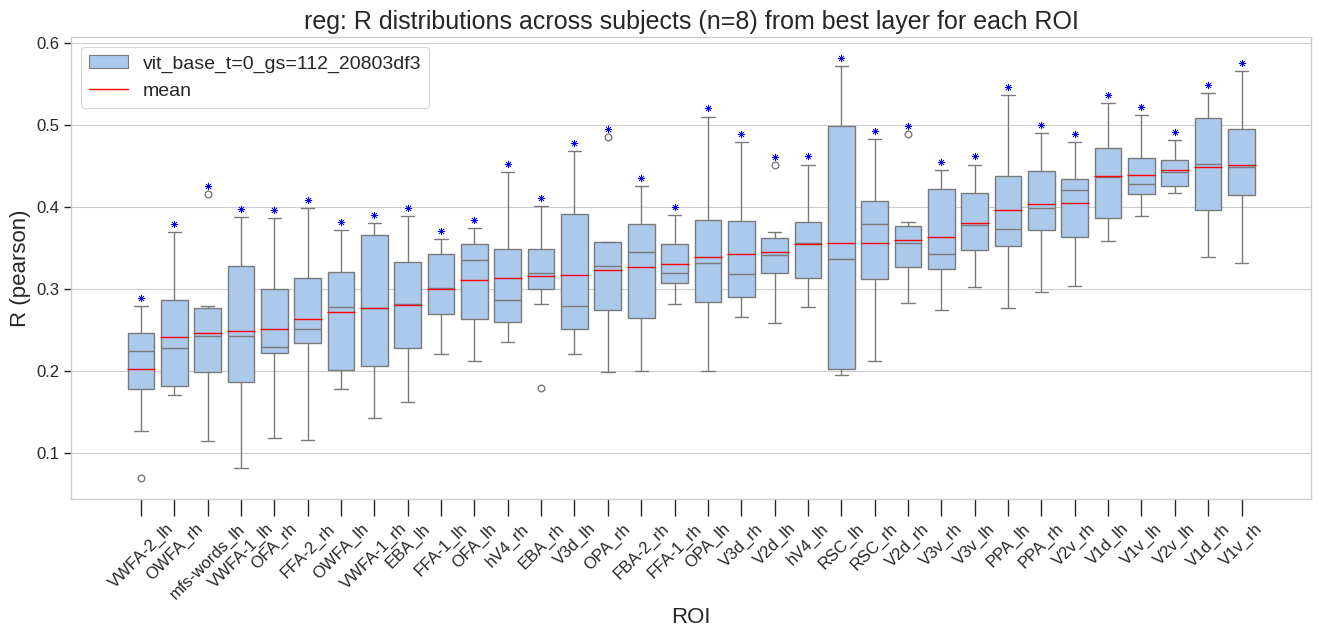

In [185]:
fig, ax = plt.subplots(figsize = (16,6))

sns.boxplot(x="ROI", y="R", hue="Model", palette='pastel', data=plotting_df_rsa, showmeans=True, meanprops={"marker":"_", 
                       "markeredgecolor":"red",
                      "markersize":"20"}, ax=ax)

rois=plotting_df_rsa["ROI"].unique()

#rois, idx = np.unique(plotting_df_rsa["ROI"].to_numpy(), return_index=True)
x = np.arange(len(rois))
y = plotting_df_rsa.groupby("ROI", sort=False)["R"].agg("max")+0.01
y.reset_index(inplace=True, drop=True)
mask = plotting_df_rsa.groupby("ROI", sort=False)["Significance"].agg("first") < 0.05
mask.reset_index(inplace=True, drop=True)
ax.scatter(x[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')

#ax.hlines(plotting_df["LNC"].iloc[idx], x-0.3, x+0.3, color='k', ls='--')
#ax.hlines(plotting_df["UNC"].iloc[idx], x-0.3, x+0.3, color='k', ls='--')

ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (pearson)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
current_handles_labels = ax.get_legend_handles_labels()
obj_list = [current_handles_labels[0][0], Line2D([0], [0], color="red", lw=1)]
label_list = [current_handles_labels[1][0], "mean"]
plt.legend(obj_list, label_list, fontsize=14, frameon=True)
ax.set_title("rsa: R distributions across subjects (n=8) from best layer for each ROI", fontsize=18)
plt.savefig(os.path.join("results",results_dir, "rsa_R_distribution_all_ROIs.pdf"), format='PDF', bbox_inches='tight')
#plt.show()

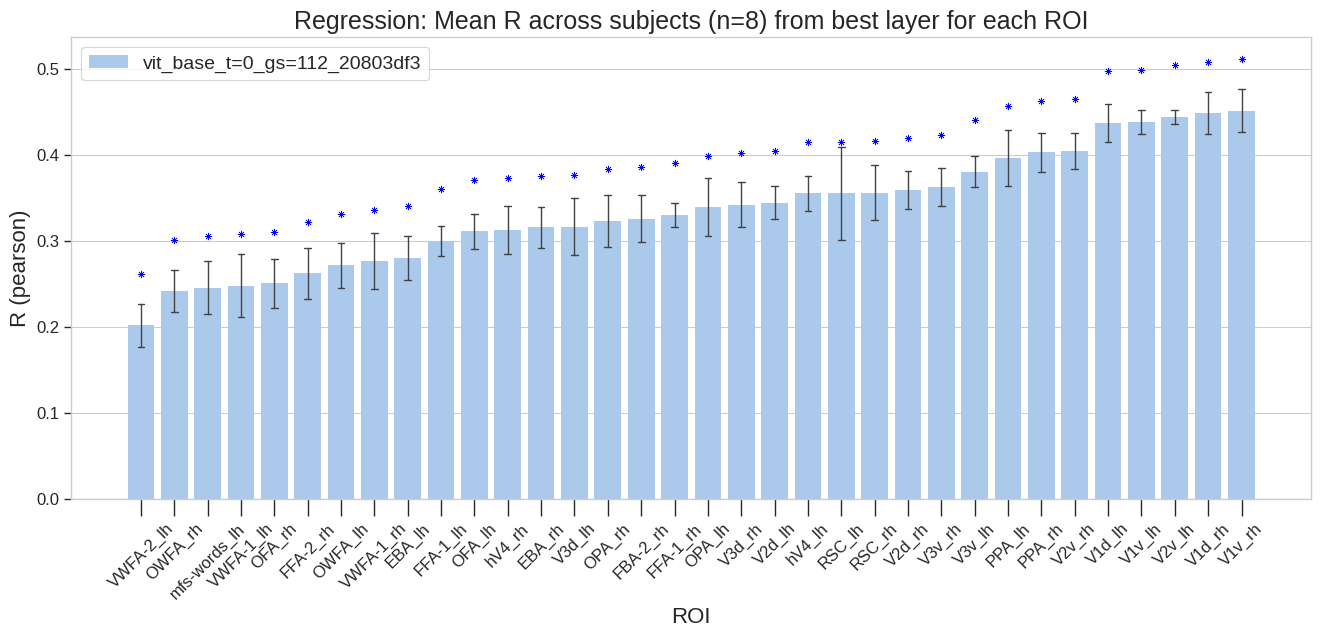

In [ ]:
fig, ax = plt.subplots(figsize=(16,6))
sns.barplot(x="ROI", y="R", hue="Model", palette='pastel', data=plotting_df_rsa, errorbar='se', capsize=0.2, errwidth=1)
rois=plotting_df_rsa["ROI"].unique()
x = np.arange(len(rois))
y = plotting_df_rsa.groupby("ROI", sort=False)["R"].agg("mean")+0.06
y.reset_index(inplace=True, drop=True)
mask = plotting_df_rsa.groupby("ROI", sort=False)["Significance"].agg("first") < 0.05
mask.reset_index(inplace=True, drop=True)
ax.scatter(x[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')

#ax.hlines(plotting_df_rsa.groupby("ROI").agg("first")["LNC"].reindex(rois), x-0.35, x+0.35, color='k', ls='dotted', label="noise ceiling")
#ax.hlines(plotting_df_rsa.groupby("ROI").agg("first")["UNC"].reindex(rois), x-0.35, x+0.35, color='k', ls='dotted')
ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (pearson)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
plt.legend(frameon=True, fontsize=14)
ax.set_title("rsa: Mean R across subjects (n=8) from best layer for each ROI", fontsize=18)
plt.savefig(os.path.join("results",results_dir, "rsa_Mean_R_all_ROIs.pdf"), format='PDF', bbox_inches='tight')

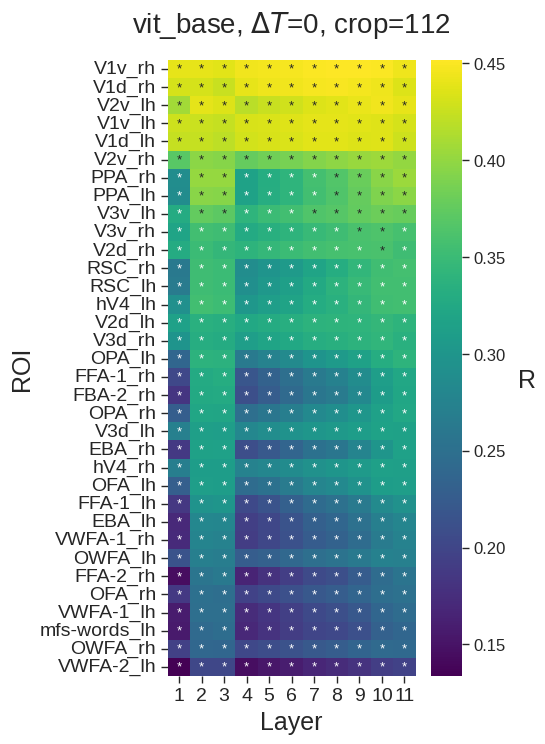

In [188]:
table = pd.pivot_table(rsa_df_fdr, values="R", columns="Layer", index="ROI")
sorter=table.max(axis=1).sort_values(ascending=False)
table_sorted = table.loc[sorter.index,:]

p_table = pd.pivot_table(rsa_df_fdr, values="Significance", columns="Layer", index="ROI") < 0.05
p_table_sorted = p_table.loc[sorter.index,:]
p_table_sorted[p_table_sorted==1]="*"

#annot = pd.pivot_table(rsa_pooled_fdr, values="SEM", columns="Layer", index="ROI")
#annot_sorted = annot.loc[sorted.index,:]

fig, ax = plt.subplots(figsize=(4,8))
sns.heatmap(table_sorted, cmap=sns.color_palette("viridis", as_cmap=True), annot=p_table_sorted, fmt="")
cbar = ax.collections[0].colorbar
cbar.set_label("R", rotation=0, labelpad=15)
ax.set_xticklabels([str(i) for i in range(1,len(table.columns)+1)], rotation=0)
ax.tick_params(axis='both',labelsize=14)
cax = ax.figure.axes[-1]
cax.tick_params(labelsize=12)
cax.set_label("R")
ax.set_title(f"{meta_rsa['name']}, $\Delta T$={meta_rsa['time_window']}, crop={meta_rsa['crop_size']}", pad=20)
plt.savefig(os.path.join("results",results_dir, "rsa_R_by_Layer_all_ROIs.pdf"), format='PDF', bbox_inches='tight')

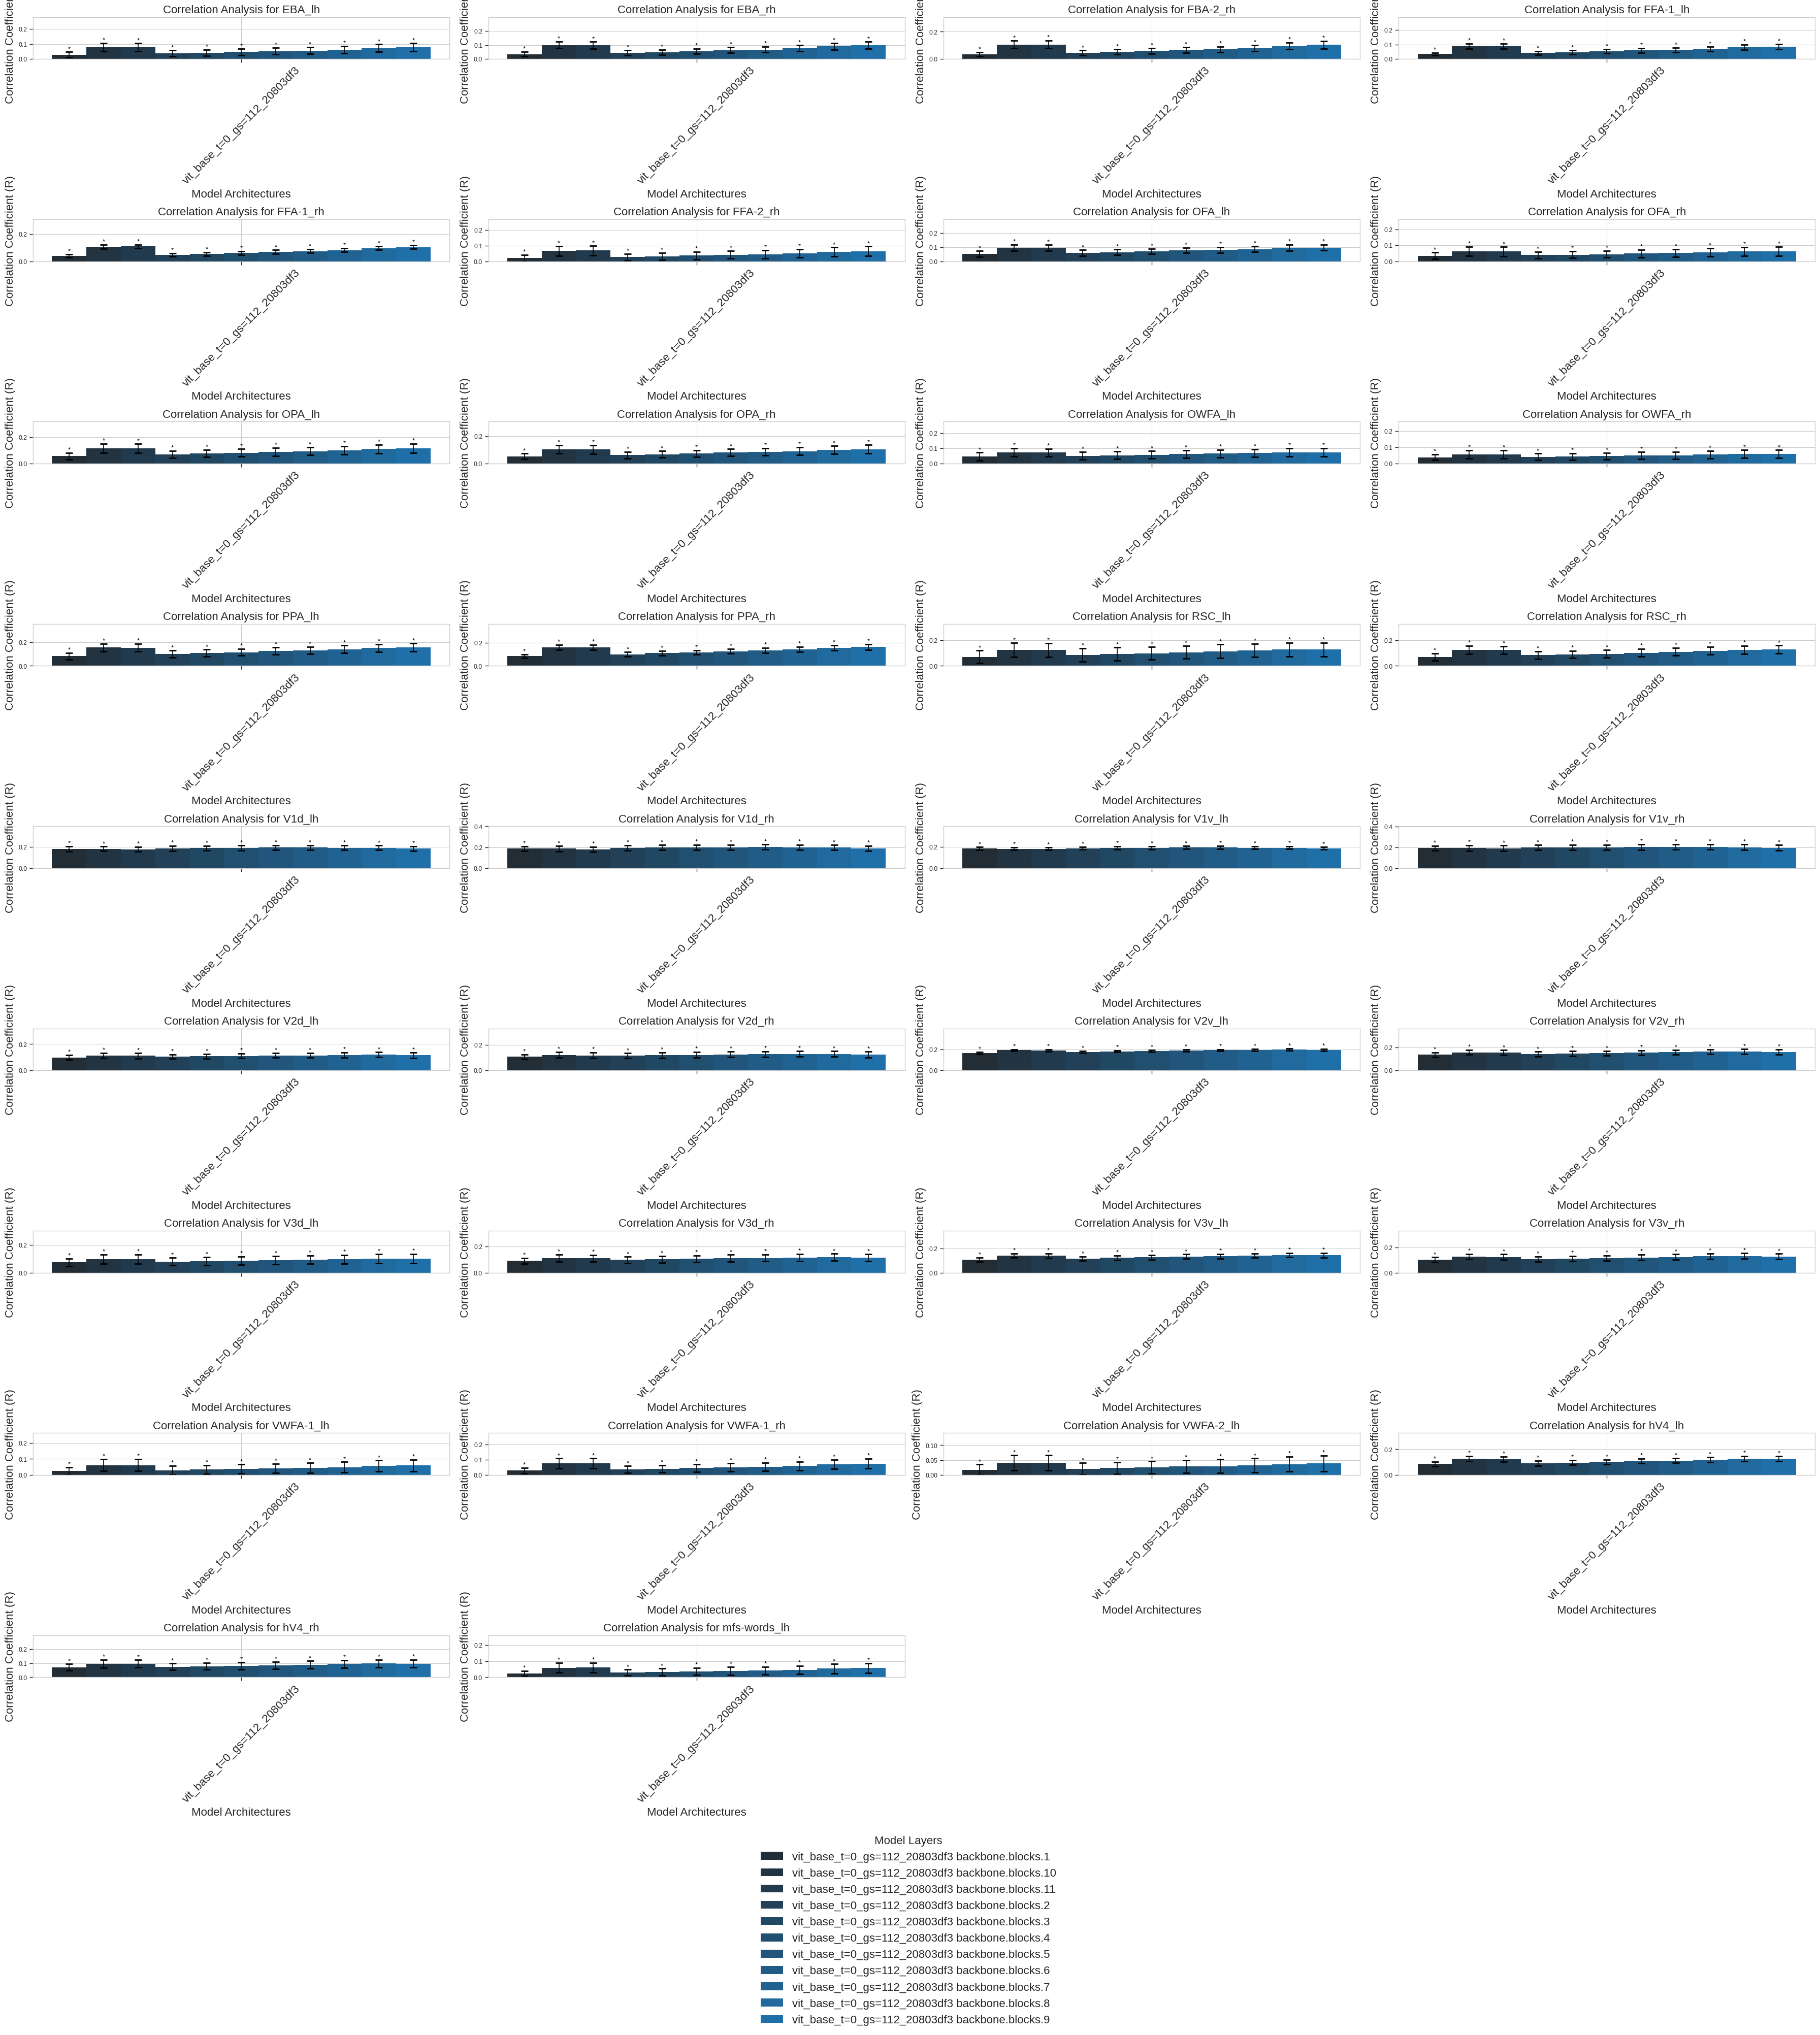

In [92]:
plotter = Plotting([rsa_df_fdr])
results_dataframe = plotter.plot_all_layers()

# Plotting results for pooled left/right

In [14]:
plotting_pooled = rsa_pooled_fdr.copy()
plotting_pooled = plotting_pooled.loc[plotting_pooled.groupby('ROI')["R"].idxmax()]
plotting_pooled.sort_values("R", inplace=True)
plotting_pooled = plotting_pooled.explode("R_array")
plotting_pooled = plotting_pooled.rename(columns = {"R": "R_mean", "%R": "%R_mean", "R_array": "R"})
plotting_pooled.reset_index(inplace=True, drop=True)

In [16]:
plotting_pooled

,ROI,Layer,Model,R_mean,%R_mean,R,Significance,LNC,SEM,UNC
0,VWFA-2,backbone.layer4,resnet50_t=5_gs=224_99e6c1e4,0.223905,NaN,0.235582,5.638625e-05,NaN,0.025116,NaN
1,VWFA-2,backbone.layer4,resnet50_t=5_gs=224_99e6c1e4,0.223905,NaN,0.270426,5.638625e-05,NaN,0.025116,NaN
2,VWFA-2,backbone.layer4,resnet50_t=5_gs=224_99e6c1e4,0.223905,NaN,0.196425,5.638625e-05,NaN,0.025116,NaN
3,VWFA-2,backbone.layer4,resnet50_t=5_gs=224_99e6c1e4,0.223905,NaN,0.250559,5.638625e-05,NaN,0.025116,NaN
4,VWFA-2,backbone.layer4,resnet50_t=5_gs=224_99e6c1e4,0.223905,NaN,0.310258,5.638625e-05,NaN,0.025116,NaN
...,...,...,...,...,...,...,...,...,...,...
147,V1v,backbone.layer3,resnet50_t=5_gs=224_99e6c1e4,0.436428,NaN,0.432126,1.285862e-07,NaN,0.014660,NaN
148,V1v,backbone.layer3,resnet50_t=5_gs=224_99e6c1e4,0.436428,NaN,0.48783,1.285862e-07,NaN,0.014660,NaN
149,V1v,backbone.layer3,resnet50_t=5_gs=224_99e6c1e4,0.436428,NaN,0.421637,1.285862e-07,NaN,0.014660,NaN
150,V1v,backbone.layer3,resnet50_t=5_gs=224_99e6c1e4,0.436428,NaN,0.402905,1.285862e-07,NaN,0.014660,NaN


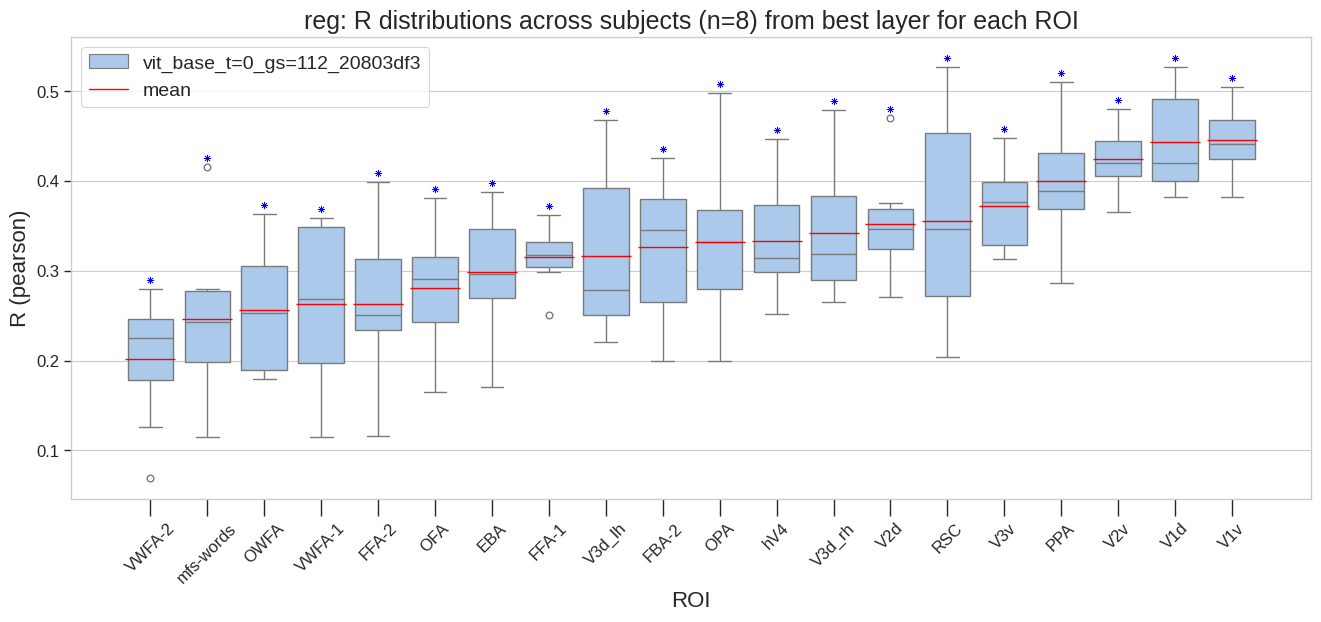

In [248]:
fig, ax = plt.subplots(figsize = (16,6))

sns.boxplot(x="ROI", y="R", hue="Model", palette='pastel', data=plotting_pooled, showmeans=True, meanprops={"marker":"_", 
                       "markeredgecolor":"red",
                      "markersize":"36"}, ax=ax)


rois=plotting_pooled["ROI"].unique()
x = np.arange(len(rois))
y = plotting_pooled.groupby("ROI", sort=False)["R"].agg("max")+0.01
y.reset_index(inplace=True, drop=True)
mask = plotting_pooled.groupby("ROI", sort=False)["Significance"].agg("first") < 0.05
mask.reset_index(inplace=True, drop=True)
ax.scatter(x[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')

#ax.hlines(plotting_df["LNC"].iloc[idx], x-0.3, x+0.3, color='k', ls='--')
#ax.hlines(plotting_df["UNC"].iloc[idx], x-0.3, x+0.3, color='k', ls='--')

ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (pearson)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
current_handles_labels = ax.get_legend_handles_labels()
obj_list = [current_handles_labels[0][0], Line2D([0], [0], color="red", lw=1)]
label_list = [current_handles_labels[1][0], "mean"]
plt.legend(obj_list, label_list, fontsize=14, frameon=True)
ax.set_title("rsa: R distributions across subjects (n=8) from best layer for each ROI", fontsize=18)
plt.savefig(os.path.join("results",results_dir, "rsa_R_distribution_pooled.pdf"), format='PDF', bbox_inches='tight')
#plt.show()

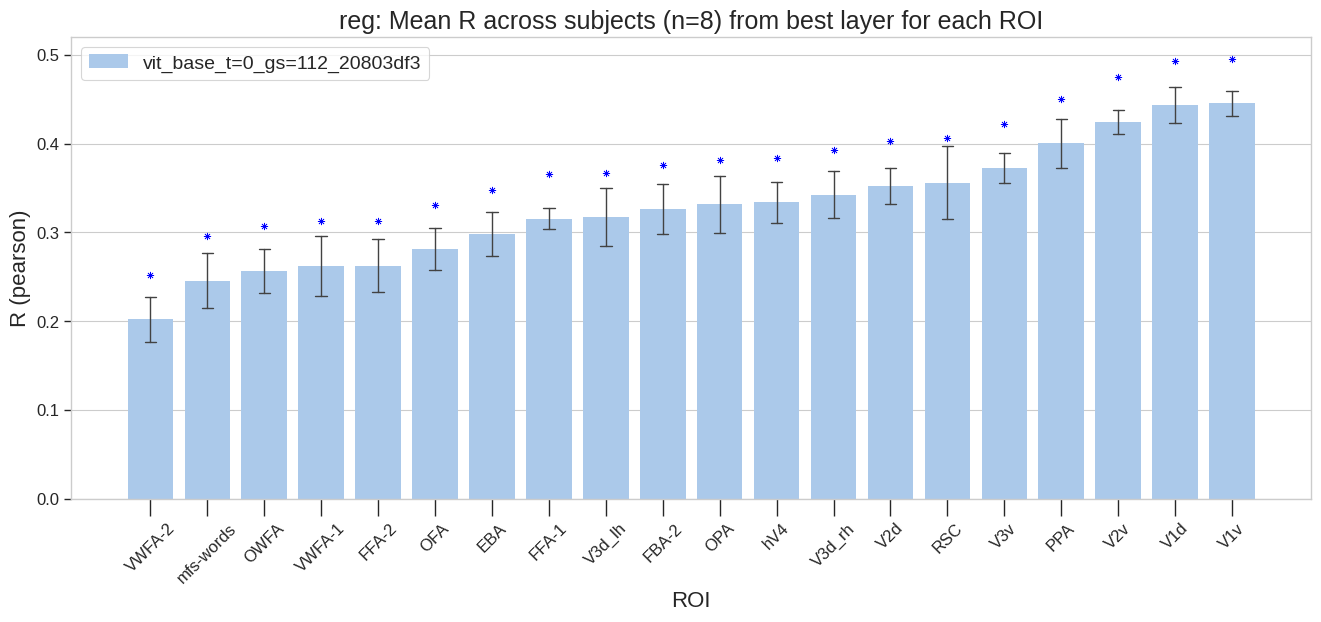

In [249]:
fig, ax = plt.subplots(figsize=(16,6))
sns.barplot(x="ROI", y="R", hue="Model", palette='pastel', data=plotting_pooled, errorbar='se', capsize=0.2, errwidth=1)
rois=plotting_pooled["ROI"].unique()
x = np.arange(len(rois))
y = plotting_pooled.groupby("ROI", sort=False)["R"].agg("mean")+0.05
y.reset_index(inplace=True, drop=True)
mask = plotting_pooled.groupby("ROI", sort=False)["Significance"].agg("first") < 0.05
mask.reset_index(inplace=True, drop=True)
ax.scatter(x[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')

#ax.hlines(plotting_pooled.groupby("ROI")["LNC"].agg("first").reindex(rois), x-0.35, x+0.35, color='k', ls='dotted', label="noise ceiling")
#ax.hlines(plotting_pooled.groupby("ROI")["UNC"].agg("first").reindex(rois), x-0.35, x+0.35, color='k', ls='dotted')
ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (pearson)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
plt.legend(frameon=True, fontsize=14)
ax.set_title("rsa: Mean R across subjects (n=8) from best layer for each ROI", fontsize=18)
plt.savefig(os.path.join("results",results_dir, "rsa_Mean_R_pooled.pdf"), format='PDF', bbox_inches='tight')

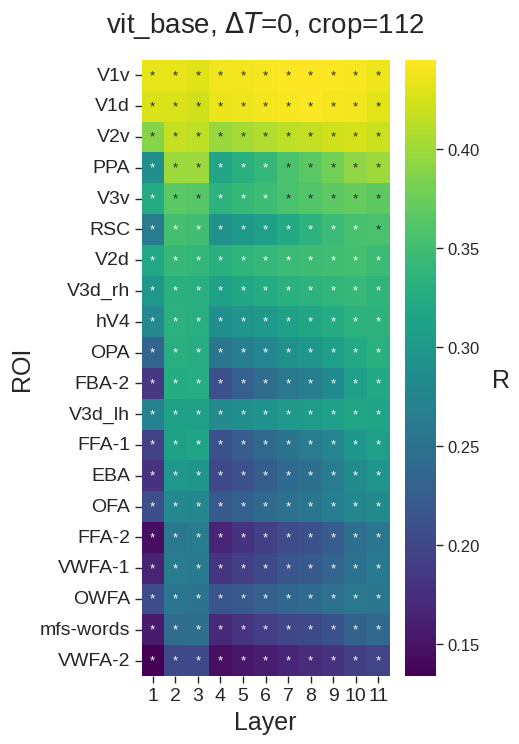

In [208]:
table = pd.pivot_table(rsa_pooled_fdr, values="R", columns="Layer", index="ROI")
sorted=table.max(axis=1).sort_values(ascending=False)
table_sorted = table.loc[sorted.index,:]

p_table = pd.pivot_table(rsa_pooled_fdr, values="Significance", columns="Layer", index="ROI") < 0.05
p_table_sorted = p_table.loc[sorted.index,:]
p_table_sorted[p_table_sorted==1]="*"

#annot = pd.pivot_table(rsa_pooled_fdr, values="SEM", columns="Layer", index="ROI")
#annot_sorted = annot.loc[sorted.index,:]

fig, ax = plt.subplots(figsize=(4,8))
sns.heatmap(table_sorted, cmap=sns.color_palette("viridis", as_cmap=True), annot=p_table_sorted, fmt="")
cbar = ax.collections[0].colorbar
cbar.set_label("R", rotation=0, labelpad=15)
ax.set_xticklabels([str(i) for i in range(1,len(table.columns)+1)], rotation=0)
ax.tick_params(axis='both',labelsize=14)
cax = ax.figure.axes[-1]
cax.tick_params(labelsize=12)
cax.set_label("R")
ax.set_title(f"{meta_rsa['name']}, $\Delta T$={meta_rsa['time_window']}, crop={meta_rsa['crop_size']}", pad=20)
plt.savefig(os.path.join("results",results_dir, "rsa_R_by_Layer_pooled.pdf"), format='PDF', bbox_inches='tight')
#sns.heatmap(table_sorted, cmap=sns.cubehelix_palette(start=1.6, rot=-.9, as_cmap=True, dark=0.3), vmin=0, vmax=0.2)

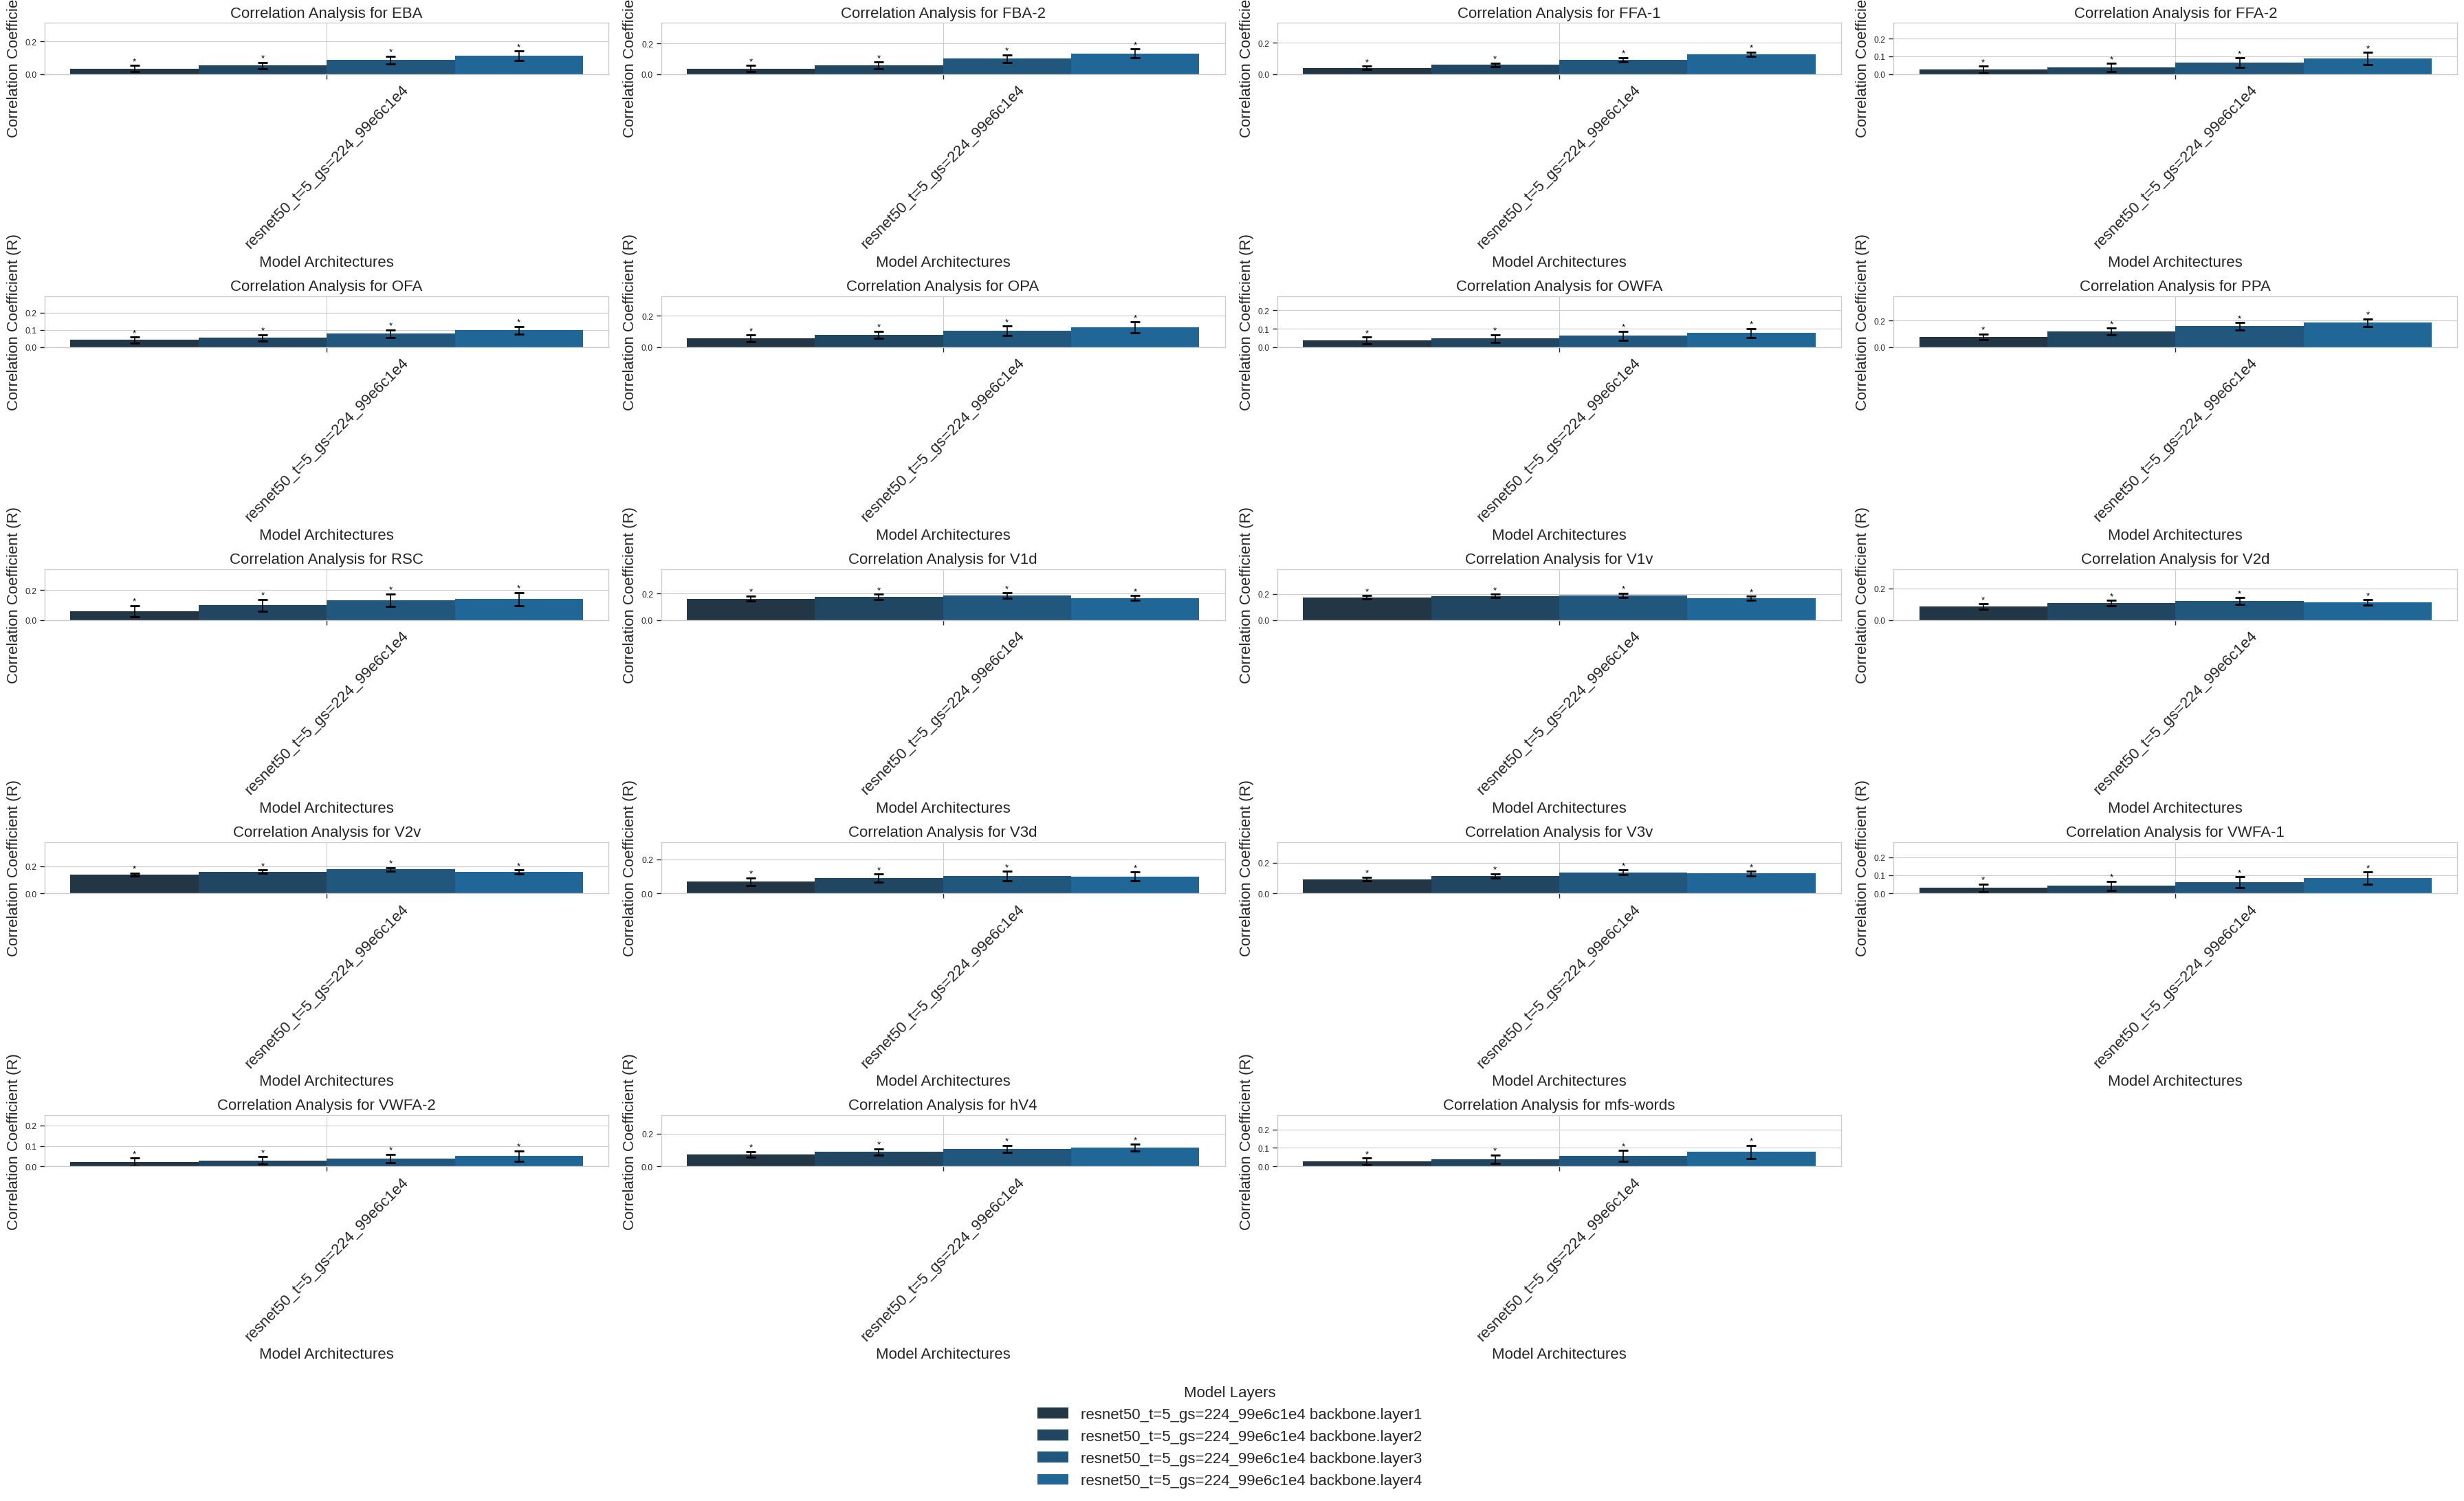

In [24]:
plotter = Plotting([rsa_pooled_fdr])
results_dataframe = plotter.plot_all_layers()

# Plotting grouped by ROI category

In [210]:
#roi_cat.set_index("ROI", inplace=True)
plotting_pooled["processing_stage"]=[roi_cat.loc[roi.split("_")[0], "processing_stage"] for roi in plotting_pooled["ROI"].to_list()]
plotting_pooled["location/stream"]=[roi_cat.loc[roi.split("_")[0], "location/stream"] for roi in plotting_pooled["ROI"].to_list()]

In [211]:
plotting_pooled = rsa_pooled_fdr.copy()
plotting_pooled = plotting_pooled.loc[plotting_pooled.groupby('ROI')["R"].idxmax()]
plotting_pooled.reset_index(inplace=True, drop=True)

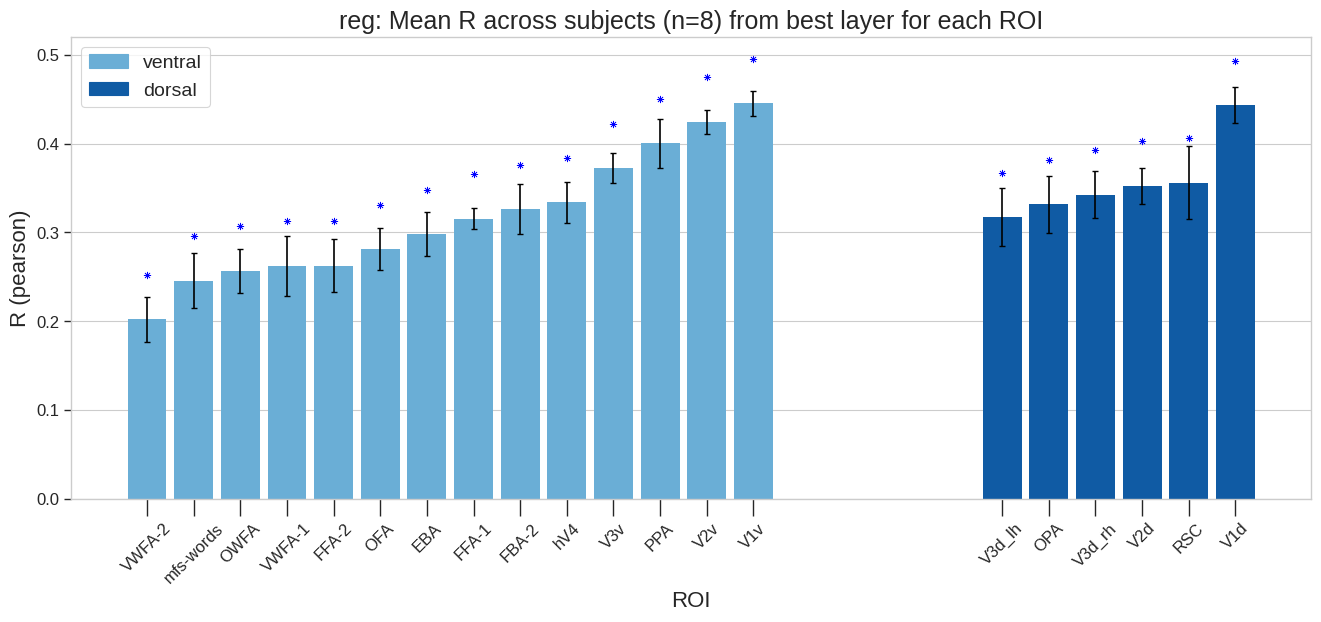

In [212]:
#palette = sns.color_palette("pastel")
palette = sns.color_palette("Blues", n_colors=5)

fig, ax = plt.subplots(figsize=(16,6))

count_v = 0
count_d = 0
loc_v = 1
loc_d = 12
xtick_loc = []
xtick_labels = []
rois = plotting_pooled.sort_values('R')["ROI"].to_numpy()

for roi in rois:
    if roi_cat.loc[roi.split("_")[0],"location/stream"]=="ventral":
        loc = loc_v + count_v
        xtick_loc.append(loc)
        xtick_labels.append(roi)
        ax.bar(loc, plotting_pooled["R"].loc[plotting_pooled["ROI"]==roi],
               color=palette[2], 
               width=0.5, 
               yerr=plotting_pooled["SEM"].loc[plotting_pooled["ROI"]==roi], 
               capsize=2)
        count_v += 0.6
    else:
        loc = loc_d + count_d
        xtick_loc.append(loc)
        xtick_labels.append(roi)
        ax.bar(loc, plotting_pooled["R"].loc[plotting_pooled["ROI"]==roi],
               color=palette[4], width=0.5, 
               yerr=plotting_pooled["SEM"].loc[plotting_pooled["ROI"]==roi], 
               capsize=2)
        count_d += 0.6

#ax.plot([1 ,1,count_v+loc_v-0.6, count_v+loc_v-0.6], [-.15, -.25, -.25, -.15], linewidth=1, color='k', transform=ax.get_xaxis_transform(), clip_on=False)
#ax.plot([loc_d ,loc_d,count_d+loc_d-0.6, count_d+loc_d-0.6], [-.15, -.25, -.25, -.15], linewidth=1, color='k', transform=ax.get_xaxis_transform(), clip_on=False)
#ax.text(loc_v+(count_v)/2-0.6, -.3, "ventral", transform=ax.get_xaxis_transform(), clip_on=False, fontsize=14)
#ax.text(loc_d+(count_d)/2-0.6, -.3, "dorsal", transform=ax.get_xaxis_transform(), clip_on=False, fontsize=14)

y = plotting_pooled.sort_values('R')["R"]+0.05
mask = plotting_pooled.sort_values('R')["Significance"] < 0.05
ax.scatter(np.array(xtick_loc)[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')


ax.set_xticks(xtick_loc, xtick_labels)
ax.grid(visible=True, which='major', axis='y')
ax.grid(visible=False, axis='x')
ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (pearson)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
patches = [mpl.patches.Patch(color=palette[2], label="ventral"), mpl.patches.Patch(color=palette[4], label="dorsal")]
plt.legend(handles=patches, frameon=True, fontsize=14)
ax.set_title("rsa: Mean R across subjects (n=8) from best layer for each ROI", fontsize=18)
plt.savefig(os.path.join("results",results_dir, "rsa_Mean_R_ventral_dorsal.pdf"), format='PDF', bbox_inches='tight')

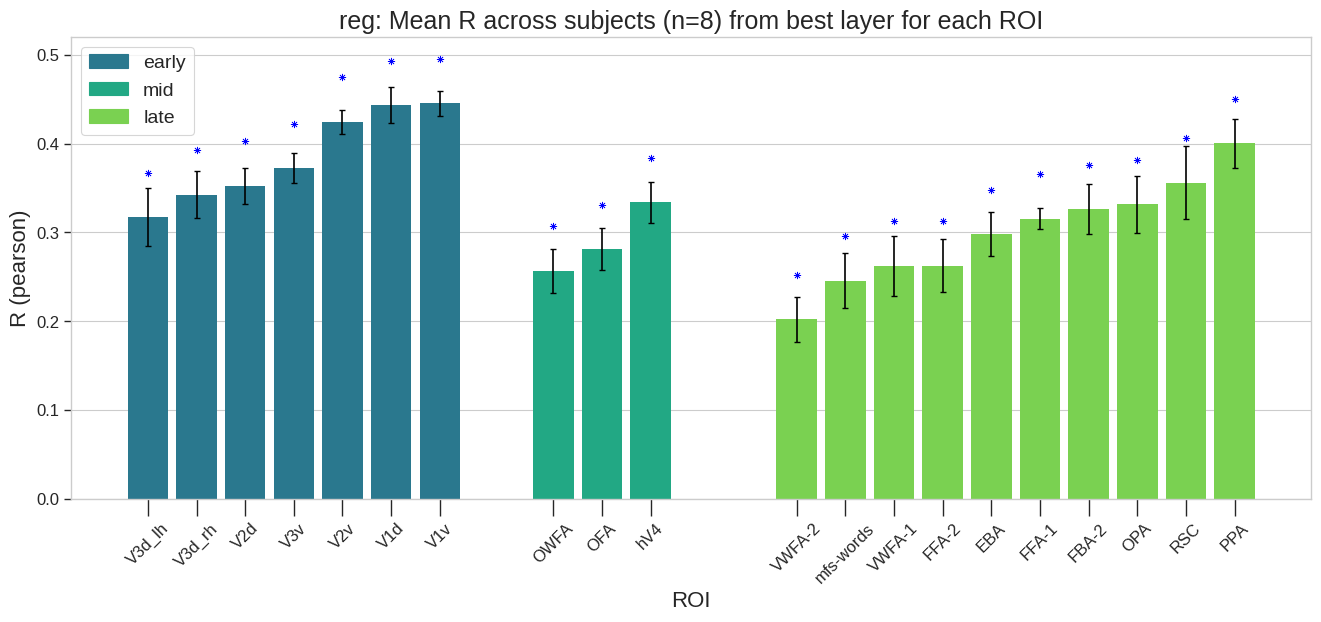

In [213]:
palette = sns.color_palette("viridis", n_colors=4)

fig, ax = plt.subplots(figsize=(16,6))

count_e = 0
count_m = 0
count_l = 0
loc_e = 1
loc_m = 6
loc_l = 9
xtick_loc = []
xtick_labels = []
rois = plotting_pooled.sort_values('R')["ROI"].to_numpy()

for roi in rois:
    if roi_cat.loc[roi.split("_")[0],"processing_stage"]=="early":
        loc = loc_e + count_e
        xtick_loc.append(loc)
        xtick_labels.append(roi)
        ax.bar(loc, plotting_pooled["R"].loc[plotting_pooled["ROI"]==roi],
               color=palette[1], 
               width=0.5, 
               yerr=plotting_pooled["SEM"].loc[plotting_pooled["ROI"]==roi], 
               capsize=2)
        count_e += 0.6
    elif roi_cat.loc[roi.split("_")[0],"processing_stage"]=="mid":
        loc = loc_m + count_m
        xtick_loc.append(loc)
        xtick_labels.append(roi)
        ax.bar(loc, plotting_pooled["R"].loc[plotting_pooled["ROI"]==roi],
               color=palette[2], 
               width=0.5, 
               yerr=plotting_pooled["SEM"].loc[plotting_pooled["ROI"]==roi], 
               capsize=2)
        count_m += 0.6
    else:
        loc = loc_l + count_l
        xtick_loc.append(loc)
        xtick_labels.append(roi)
        ax.bar(loc, plotting_pooled["R"].loc[plotting_pooled["ROI"]==roi],
               color=palette[3], width=0.5, 
               yerr=plotting_pooled["SEM"].loc[plotting_pooled["ROI"]==roi], 
               capsize=2)
        count_l += 0.6

#ax.plot([1 ,1,count_v+loc_v-0.6, count_v+loc_v-0.6], [-.15, -.25, -.25, -.15], linewidth=1, color='k', transform=ax.get_xaxis_transform(), clip_on=False)
#ax.plot([loc_d ,loc_d,count_d+loc_d-0.6, count_d+loc_d-0.6], [-.15, -.25, -.25, -.15], linewidth=1, color='k', transform=ax.get_xaxis_transform(), clip_on=False)
#ax.text(loc_v+(count_v)/2-0.6, -.3, "ventral", transform=ax.get_xaxis_transform(), clip_on=False, fontsize=14)
#ax.text(loc_d+(count_d)/2-0.6, -.3, "dorsal", transform=ax.get_xaxis_transform(), clip_on=False, fontsize=14)

y = plotting_pooled.sort_values('R')["R"]+0.05
mask = plotting_pooled.sort_values('R')["Significance"] < 0.05
ax.scatter(np.array(xtick_loc)[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')


ax.set_xticks(xtick_loc, xtick_labels)
ax.grid(visible=True, which='major', axis='y')
ax.grid(visible=False, axis='x')
ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (pearson)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
patches = [mpl.patches.Patch(color=palette[1], label="early"), 
           mpl.patches.Patch(color=palette[2], label="mid"),
           mpl.patches.Patch(color=palette[3], label="late")]
plt.legend(handles=patches, frameon=True, fontsize=14)
ax.set_title("rsa: Mean R across subjects (n=8) from best layer for each ROI", fontsize=18)
plt.savefig(os.path.join("results",results_dir, "rsa_Mean_R_early_mid_late.pdf"), format='PDF', bbox_inches='tight')

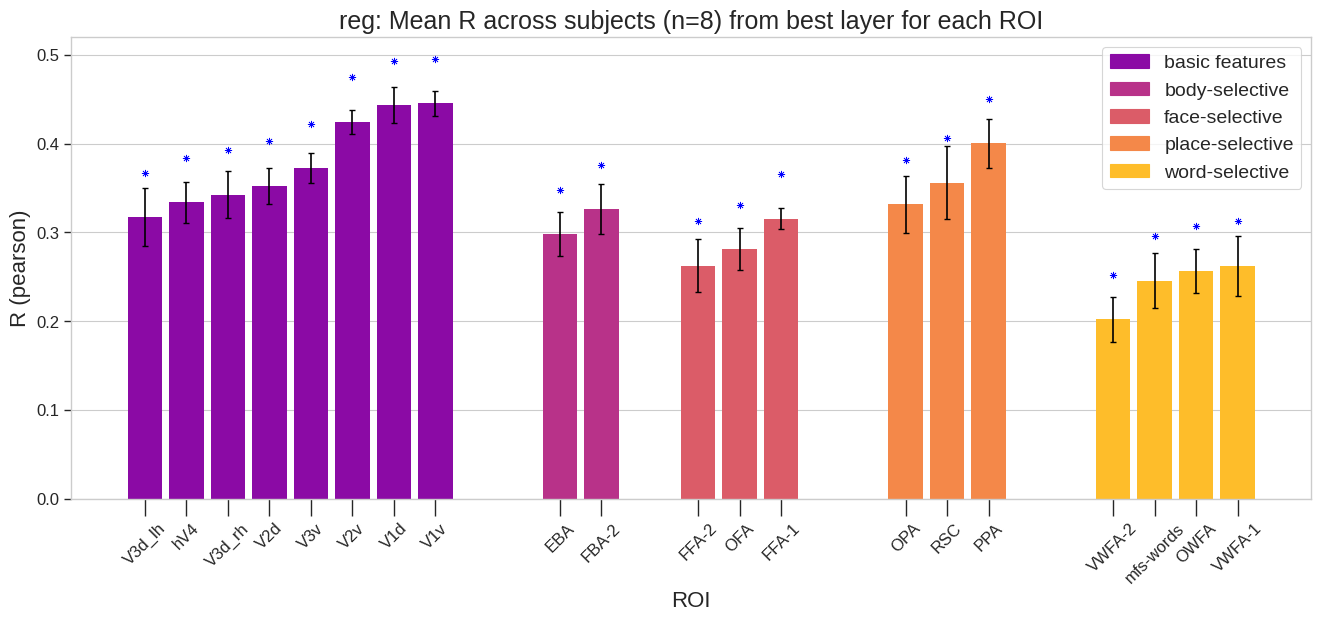

In [215]:
palette = sns.color_palette("plasma", n_colors=6)

fig, ax = plt.subplots(figsize=(16,6))

count_0 = 0
count_b = 0
count_f = 0
count_p = 0
count_w = 0
loc_0 = 1
loc_b = 7
loc_f = 9
loc_p = 12
loc_w = 15
xtick_loc = []
xtick_labels = []
rois = plotting_pooled.sort_values('R')["ROI"].to_numpy()

for roi in rois:
    if roi_cat.loc[roi.split("_")[0],"selectivity"]=="basic features":
        loc = loc_0 + count_0
        xtick_loc.append(loc)
        xtick_labels.append(roi)
        ax.bar(loc, plotting_pooled["R"].loc[plotting_pooled["ROI"]==roi],
               color=palette[1], 
               width=0.5, 
               yerr=plotting_pooled["SEM"].loc[plotting_pooled["ROI"]==roi], 
               capsize=2)
        count_0 += 0.6
    elif roi_cat.loc[roi.split("_")[0],"selectivity"]=="body-selective":
        loc = loc_b + count_b
        xtick_loc.append(loc)
        xtick_labels.append(roi)
        ax.bar(loc, plotting_pooled["R"].loc[plotting_pooled["ROI"]==roi],
               color=palette[2], 
               width=0.5, 
               yerr=plotting_pooled["SEM"].loc[plotting_pooled["ROI"]==roi], 
               capsize=2)
        count_b += 0.6
    elif roi_cat.loc[roi.split("_")[0],"selectivity"]=="face-selective":
        loc = loc_f + count_f
        xtick_loc.append(loc)
        xtick_labels.append(roi)
        ax.bar(loc, plotting_pooled["R"].loc[plotting_pooled["ROI"]==roi],
               color=palette[3], 
               width=0.5, 
               yerr=plotting_pooled["SEM"].loc[plotting_pooled["ROI"]==roi], 
               capsize=2)
        count_f += 0.6
    elif roi_cat.loc[roi,"selectivity"]=="place-selective":
        loc = loc_p + count_p
        xtick_loc.append(loc)
        xtick_labels.append(roi)
        ax.bar(loc, plotting_pooled["R"].loc[plotting_pooled["ROI"]==roi],
               color=palette[4], 
               width=0.5, 
               yerr=plotting_pooled["SEM"].loc[plotting_pooled["ROI"]==roi], 
               capsize=2)
        count_p += 0.6
    else:
        loc = loc_w + count_w
        xtick_loc.append(loc)
        xtick_labels.append(roi)
        ax.bar(loc, plotting_pooled["R"].loc[plotting_pooled["ROI"]==roi],
               color=palette[5], width=0.5, 
               yerr=plotting_pooled["SEM"].loc[plotting_pooled["ROI"]==roi], 
               capsize=2)
        count_w += 0.6

#ax.plot([1 ,1,count_v+loc_v-0.6, count_v+loc_v-0.6], [-.15, -.25, -.25, -.15], linewidth=1, color='k', transform=ax.get_xaxis_transform(), clip_on=False)
#ax.plot([loc_d ,loc_d,count_d+loc_d-0.6, count_d+loc_d-0.6], [-.15, -.25, -.25, -.15], linewidth=1, color='k', transform=ax.get_xaxis_transform(), clip_on=False)
#ax.text(loc_v+(count_v)/2-0.6, -.3, "ventral", transform=ax.get_xaxis_transform(), clip_on=False, fontsize=14)
#ax.text(loc_d+(count_d)/2-0.6, -.3, "dorsal", transform=ax.get_xaxis_transform(), clip_on=False, fontsize=14)

y = plotting_pooled.sort_values('R')["R"]+0.05
mask = plotting_pooled.sort_values('R')["Significance"] < 0.05
ax.scatter(np.array(xtick_loc)[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')


ax.set_xticks(xtick_loc, xtick_labels)
ax.grid(visible=True, which='major', axis='y')
ax.grid(visible=False, axis='x')
ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (pearson)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
patches = [mpl.patches.Patch(color=palette[1], label="basic features"), 
           mpl.patches.Patch(color=palette[2], label="body-selective"),
           mpl.patches.Patch(color=palette[3], label="face-selective"),
           mpl.patches.Patch(color=palette[4], label="place-selective"),
           mpl.patches.Patch(color=palette[5], label="word-selective")]
plt.legend(handles=patches, frameon=True, fontsize=14)
ax.set_title("rsa: Mean R across subjects (n=8) from best layer for each ROI", fontsize=18)
plt.savefig(os.path.join("results",results_dir, "rsa_Mean_R_by_selectivity.pdf"), format='PDF', bbox_inches='tight')

In [216]:
plot_all_layers = rsa_pooled_fdr.copy()
plot_all_layers["processing_stage"]=[roi_cat.loc[roi.split("_")[0], "processing_stage"] for roi in plot_all_layers["ROI"].to_list()]
plot_all_layers["location/stream"]=[roi_cat.loc[roi.split("_")[0], "location/stream"] for roi in plot_all_layers["ROI"].to_list()]
plot_all_layers["selectivity"]=[roi_cat.loc[roi.split("_")[0], "selectivity"] for roi in plot_all_layers["ROI"].to_list()]


In [217]:
plot_all_layers=plot_all_layers.explode("R_array")

/tmp/ipykernel_2074055/3505658558.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(np.arange(1,12))
/tmp/ipykernel_2074055/3505658558.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(np.arange(1,12))
/tmp/ipykernel_2074055/3505658558.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(np.arange(1,12))
/tmp/ipykernel_2074055/3505658558.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(np.arange(1,12))
/tmp/ipykernel_2074055/3505658558.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


Text(0.5, 0.92, 'R across Layers for all ROIs')

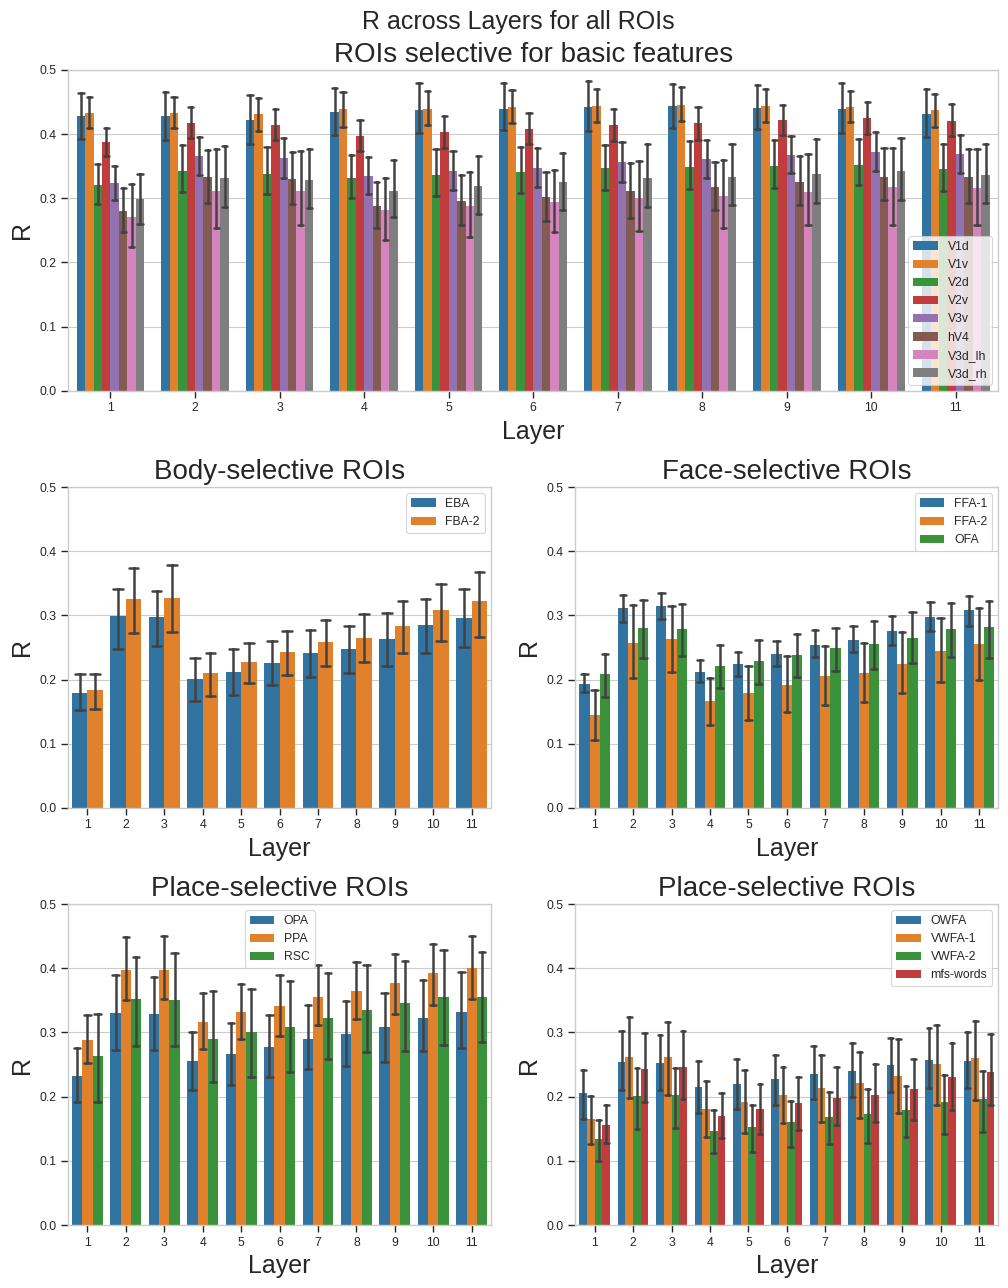

In [239]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(12,15))
gs = GridSpec(3, 2, figure=fig, hspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
sns.barplot(data=plot_all_layers.loc[plot_all_layers["selectivity"]=="basic features",:], x="Layer", y="R_array", hue="ROI", ax=ax1, capsize=0.5)
ax1.legend(frameon=True)
ax1.set_xticklabels(np.arange(1,12))
ax1.set_title("ROIs selective for basic features")
ax1.set_ylabel("R")
ax1.set_ylim(0,0.5)

ax2 = fig.add_subplot(gs[1, 0])
sns.barplot(data=plot_all_layers.loc[plot_all_layers["selectivity"]=="body-selective",:], x="Layer", y="R_array", hue="ROI", ax=ax2, capsize=0.5)
ax2.legend(frameon=True)
ax2.set_xticklabels(np.arange(1,12))
ax2.set_title("Body-selective ROIs")
ax2.set_ylabel("R")
ax2.set_ylim(0,0.5)

ax3 = fig.add_subplot(gs[1, 1])
sns.barplot(data=plot_all_layers.loc[plot_all_layers["selectivity"]=="face-selective",:], x="Layer", y="R_array", hue="ROI", ax=ax3, capsize=0.5)
ax3.legend(frameon=True)
ax3.set_xticklabels(np.arange(1,12))
ax3.set_title("Face-selective ROIs")
ax3.set_ylabel("R")
ax3.set_ylim(0,0.5)

ax4 = fig.add_subplot(gs[2, 0])
sns.barplot(data=plot_all_layers.loc[plot_all_layers["selectivity"]=="place-selective",:], x="Layer", y="R_array", hue="ROI", ax=ax4, capsize=0.5)
ax4.legend(frameon=True)
ax4.set_xticklabels(np.arange(1,12))
ax4.set_title("Place-selective ROIs")
ax4.set_ylabel("R")
ax4.set_ylim(0,0.5)

ax5 = fig.add_subplot(gs[2, 1])
sns.barplot(data=plot_all_layers.loc[plot_all_layers["selectivity"]=="word-selective",:], x="Layer", y="R_array", hue="ROI", ax=ax5, capsize=0.5)
ax5.legend(frameon=True)
ax5.set_xticklabels(np.arange(1,12))
ax5.set_title("Place-selective ROIs")
ax5.set_ylabel("R")
ax5.set_ylim(0,0.5)

plt.suptitle(f"R across Layers for all ROIs", fontsize=18, y=0.92)

# Model comparison

In [3]:
comp_dir = "results/model_comparison"
rsa_comp_table = pq.read_table(os.path.join(comp_dir, "rsa_model_comp_all.parquet"), partitioning=None)
rsa_comp = rsa_comp_table.to_pandas()

In [74]:
rsa_comp.loc[(rsa_comp["Model"]==results_dir) & (rsa_comp["ROI"]=="V3d") ,:]

,ROI,Model,Layer,R,R_array,SEM,Significance,%R,LNC,UNC,model_name,time_window,crop_size,center_crop
184,V3d,vit_base_t=0_gs=112_20803df3,backbone.blocks.8,0.329588,"[0.47380652047437366, 0.4152355061310463, 0.28...",0.029447,0.00001,NaN,NaN,NaN,vit_base,0,112,False


In [25]:
rsa_comp

,ROI,Model,Layer,R,R_array,SEM,Significance,%R,LNC,UNC,model_name,time_window,crop_size,center_crop
0,EBA,resnet50_t=5_gs=224_99e6c1e4,backbone.layer4,0.336497,"[0.3915125576165166, 0.41189766474203904, 0.32...",0.027991,6.282486e-06,NaN,NaN,NaN,resnet50,5,224,False
1,FBA-2_rh,resnet50_t=5_gs=224_99e6c1e4,backbone.layer4,0.368548,"[0.40584919165576133, 0.3631089455106002, 0.46...",0.029874,5.279302e-06,NaN,NaN,NaN,resnet50,5,224,False
2,FFA-1,resnet50_t=5_gs=224_99e6c1e4,backbone.layer4,0.354268,"[0.38188538657635596, 0.41140069459830975, 0.3...",0.014278,4.403466e-08,NaN,NaN,NaN,resnet50,5,224,False
3,FFA-2_rh,resnet50_t=5_gs=224_99e6c1e4,backbone.layer4,0.297436,"[0.445486742452246, 0.34433162960672686, 0.261...",0.034146,5.272789e-05,NaN,NaN,NaN,resnet50,5,224,False
4,OFA,resnet50_t=5_gs=224_99e6c1e4,backbone.layer4,0.313048,"[0.3609687864663026, 0.30926656693419896, 0.33...",0.023415,3.069081e-06,NaN,NaN,NaN,resnet50,5,224,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,V3v,resnet50_t=20_gs=224_8847d55e,backbone.layer3,0.367048,"[0.4346960189901533, 0.39237585837242206, 0.35...",0.014751,4.318075e-08,NaN,NaN,NaN,resnet50,20,224,False
490,VWFA-1,resnet50_t=20_gs=224_8847d55e,backbone.layer4,0.281308,"[0.3413584241033803, 0.38297343898056646, 0.19...",0.033865,7.162568e-05,NaN,NaN,NaN,resnet50,20,224,False
491,VWFA-2_lh,resnet50_t=20_gs=224_8847d55e,backbone.layer4,0.220436,"[0.22709606474708097, 0.26464953261093715, 0.1...",0.025386,5.381949e-05,NaN,NaN,NaN,resnet50,20,224,False
492,hV4,resnet50_t=20_gs=224_8847d55e,backbone.layer3,0.326010,"[0.38093670249578615, 0.4328982860039815, 0.29...",0.021542,1.322689e-06,NaN,NaN,NaN,resnet50,20,224,False


In [241]:
dir_list = [os.path.join("results", dir) for dir in os.listdir("results") if os.path.isdir(os.path.join("results", dir))]

non_poolable_all = []
for dir in dir_list:
    if dir == os.path.join("results", "model_comparison"):
        continue
    rsa_table = pq.read_table(os.path.join(dir, "eval_df_rsa.parquet"), partitioning=None)
    rsa_df = rsa_table.to_pandas()
    rsa_df.reset_index(inplace=True, drop=True)
    roi_list_lh = rsa_df["ROI"].apply(lambda x: x.split("_lh")[0]).unique()
    roi_list_rh = rsa_df["ROI"].apply(lambda x: x.split("_rh")[0]).unique()
    intersect_roi = np.intersect1d(roi_list_lh, roi_list_rh)

    pool_or_not = rsa_df.copy()
    pool_or_not["ROI_non_handed"] = pool_or_not["ROI"].apply(lambda x: x[:-3])
    pool_or_not = pool_or_not.loc[pool_or_not["ROI_non_handed"].isin(intersect_roi),:]
    pool_or_not = pool_or_not.groupby(["ROI_non_handed", "Layer"])["R_array"].agg(agg_ttest)
    pool_or_not = pool_or_not.reset_index()
    pool_or_not=pool_or_not.rename(columns={"R_array": "p-value"})
    pool_or_not["p-value_FDR"]=false_discovery_control(pool_or_not["p-value"])
    non_poolable=pool_or_not.loc[pool_or_not["p-value_FDR"]<0.05,"ROI_non_handed"].to_list()
    non_poolable_all+=non_poolable
    if len(non_poolable)>0:
        print(pool_or_not.loc[pool_or_not["p-value_FDR"]<0.05,"Layer"].to_list())

print(non_poolable_all)

['backbone.blocks.2', 'backbone.blocks.3', 'backbone.blocks.4', 'backbone.blocks.5']
['V3d', 'V3d', 'V3d', 'V3d']


In [6]:
roi_dropdown = widgets.Dropdown(
    options=rsa_comp["ROI"].unique(),
    disabled=False,
)

display(roi_dropdown)

Dropdown(options=('EBA', 'FBA-2_rh', 'FFA-1', 'FFA-2_rh', 'OFA', 'OPA', 'OWFA', 'PPA', 'RSC', 'V1d', 'V1v', 'V…

In [7]:
roi = roi_dropdown.value

In [37]:
roi_df = rsa_comp.loc[rsa_comp["ROI"]==roi,:].copy()
roi_df.reset_index(inplace=True, drop=True)
# fdr correct within ROI
roi_df["Significance"]=false_discovery_control(roi_df["Significance"])


In [38]:
M = np.zeros((26,26))
sign_corr = np.zeros((26,26))
for i, row_1 in roi_df.iterrows():
    for j, row_2 in roi_df.iterrows():
        M[i,j]=ttest_rel(row_1["R_array"], row_2["R_array"])[1]
        sign_corr[i,j]=np.sign(row_1["R"] - row_2["R"])

In [39]:
tril_idx = np.tril_indices(26, k=-1)
p_value_FDR = false_discovery_control(M[tril_idx], axis=None)
M=np.zeros((26,26))
M[tril_idx[0], tril_idx[1]]=p_value_FDR
p_value_df=pd.DataFrame(M, index=roi_df["Model"], columns=roi_df["Model"])

In [40]:
p_value_df.mask(p_value_df>=0.05, 0.051, inplace=True)


In [41]:
p_value_df=p_value_df*sign_corr

In [42]:
p_value_df

Model,resnet50_t=5_gs=224_99e6c1e4,vit_base_t=15_gs=224_ed1a41d3_center_crop,vit_base_t=15_gs=336_3f0b6c26,vit_base_t=20_gs=224_920653df,resnet50_t=15_gs=224_7c077e46,vit_base_t=10_gs=224_3c26bd20,resnet50_t=25_gs=224_b274a811,resnet50_t=15_gs=112_be272581,resnet50_t=0_gs=224_c55ac28d,vit_base_t=0_gs=112_20803df3,...,vit_base_t=15_gs=540_93cbf2f7,vit_base_t=5_gs=224_ecd0ff71,vit_base_t=0_gs=224_29bdaddc,resnet50_t=10_gs=224_68c320f1,resnet50_t=0_gs=540_c44fb9fe,resnet50_t=15_gs=224_48c04639_center_crop,vit_base_t=25_gs=224_eeee0547,resnet50_t=15_gs=540_9d4d1dfc,vit_base_t=15_gs=448_3e76b2d7,resnet50_t=20_gs=224_8847d55e
Model,,,,,,,,,,,,,,,,,,,,,
resnet50_t=5_gs=224_99e6c1e4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.0
vit_base_t=15_gs=224_ed1a41d3_center_crop,-0.001045,0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.0
vit_base_t=15_gs=336_3f0b6c26,-0.003277,0.000443,0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,...,0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.0
vit_base_t=20_gs=224_920653df,-0.001405,0.025460,-0.001942,0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,-0.0
resnet50_t=15_gs=224_7c077e46,-0.051000,0.001122,0.005633,0.002254,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.0
vit_base_t=10_gs=224_3c26bd20,-0.000288,0.051000,-0.000396,-0.051000,-0.000365,0.000000,-0.000000,0.000000,-0.000000,0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.0
resnet50_t=25_gs=224_b274a811,-0.003053,0.001343,0.010815,0.003199,-0.006822,0.000287,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.0
resnet50_t=15_gs=112_be272581,-0.000241,-0.051000,-0.000165,-0.005708,-0.000259,-0.007194,-0.000229,0.000000,-0.000000,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.0
resnet50_t=0_gs=224_c55ac28d,-0.002087,0.007620,0.051000,0.021516,-0.002739,0.002779,-0.051000,0.001122,0.000000,0.000000,...,0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,-0.0


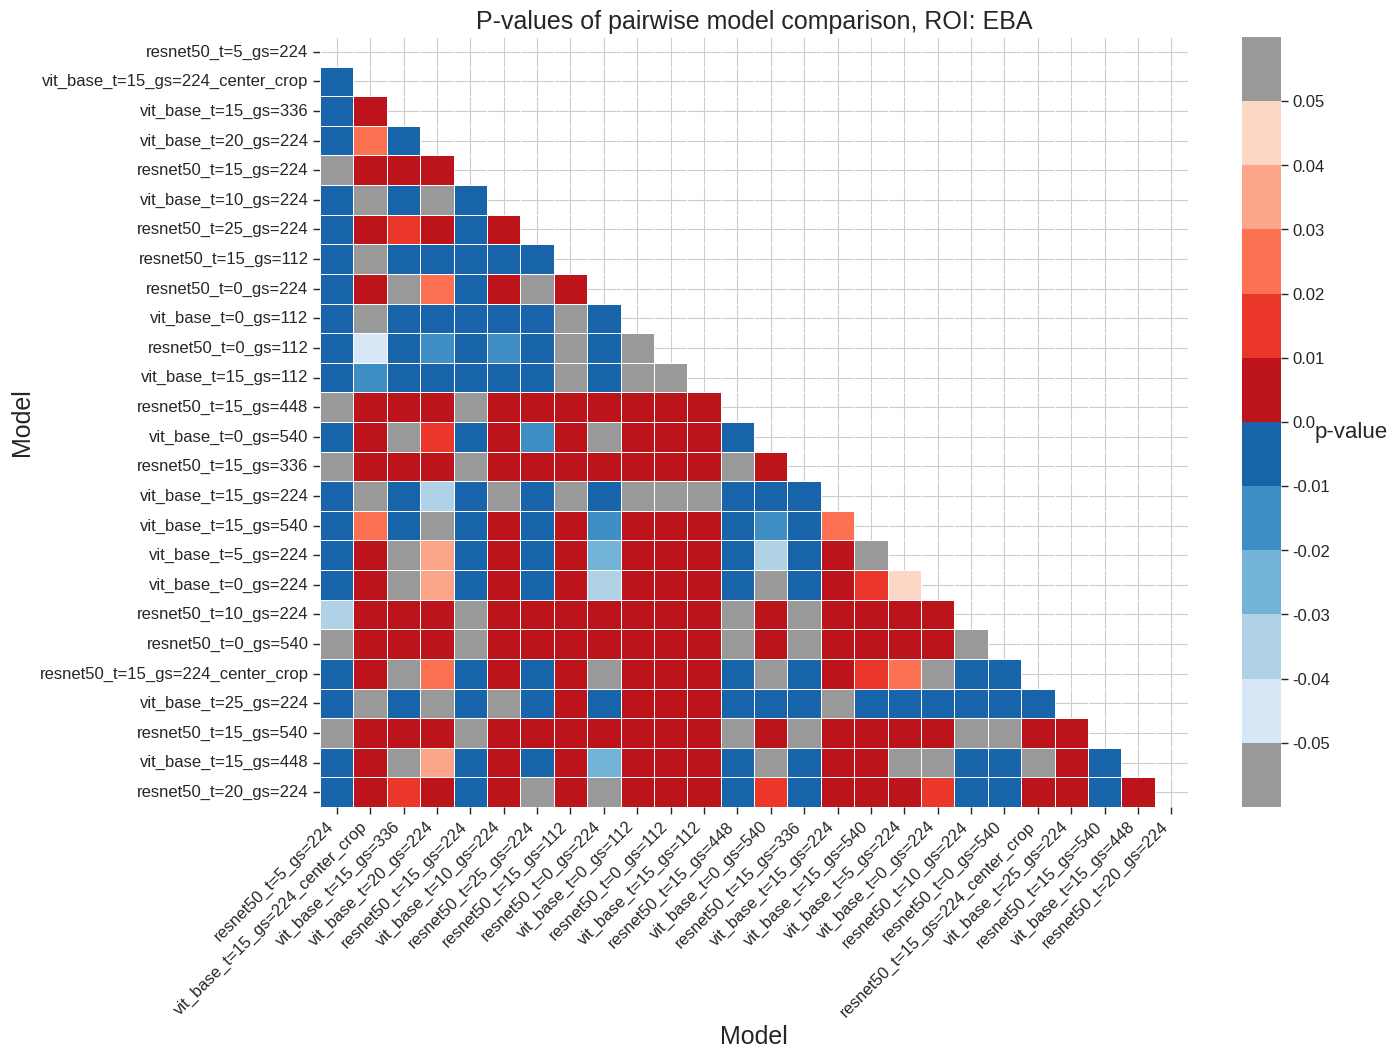

In [43]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.colors import Normalize, FuncNorm, ListedColormap, BoundaryNorm

colors1 = plt.cm.Blues(np.linspace(0, 0.8, 6))
colors1[0,:]=[0.6, 0.6, 0.6, 1]
colors2 = plt.cm.Reds_r(np.linspace(0.2, 1, 6))
colors2[-1,:]=[0.6, 0.6, 0.6, 1]

#colors1 = plt.get_cmap('Blues', 5)
#colors2 = plt.get_cmap('Reds_r', 5)

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
#mymap = LinearSegmentedColormap.from_list('my_colormap', colors)
mymap = ListedColormap(colors)


mask = np.triu(np.ones(p_value_df.shape, dtype=bool))
palette = sns.color_palette("coolwarm", n_colors=8)
#palette[5] = 'darkgray'
fig, ax = plt.subplots(figsize=(14,10))
sns.heatmap(p_value_df, annot=False, fmt=".2f", cmap=mymap, cbar=True, ax=ax, linewidths=0.5, vmin=-0.06, vmax=0.06, mask=mask)
model_labels = pd.Series(p_value_df.index).apply(strip_hash).to_list()
ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(model_labels, fontsize=12)
cbar = ax.collections[0].colorbar
cbar.set_label('p-value', rotation=0, labelpad=15)
cbar_ticklabels = list(np.round(np.arange(-0.050, 0.051, 0.01),2))
cbar_ticks = list(np.arange(-0.05, 0.051, 0.01))
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels(cbar_ticklabels, fontsize=12)
cbar.set_label("p-value", fontsize=16)
ax.set_title(f"P-values of pairwise model comparison, ROI: {roi}", fontsize=18)
#plt.savefig(f"results/model_comparison/{roi}_all_models_p_values.pdf", format='PDF', bbox_inches='tight')
plt.show()

In [18]:
roi_df_expl = roi_df.sort_values("R")
roi_df_expl = roi_df_expl.explode("R_array")
roi_df_expl.reset_index(inplace=True, drop=True)

NameError: name 'roi_df' is not defined

/tmp/ipykernel_2027609/2916538841.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels)


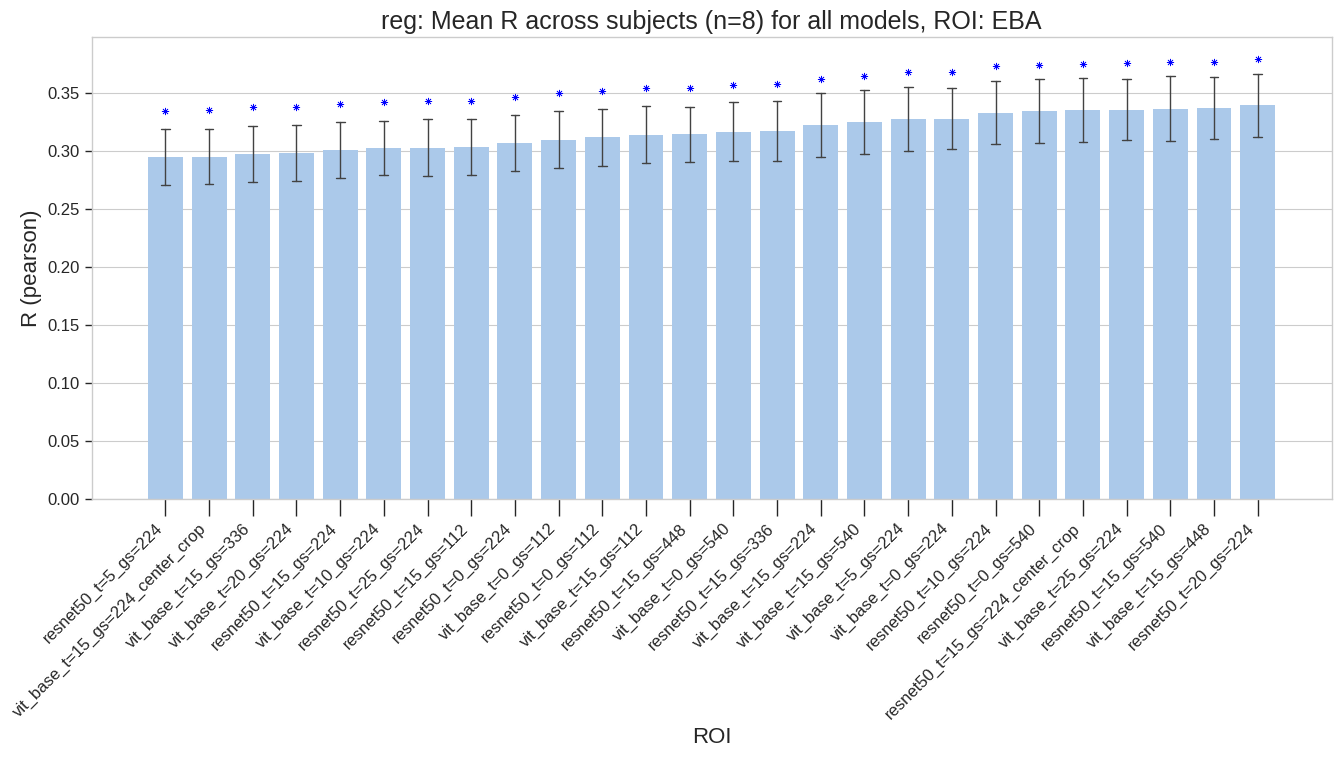

In [45]:
palette = sns.color_palette('pastel')
fig, ax = plt.subplots(figsize=(16,6))
sns.barplot(x="Model", y="R_array", color=palette[0], data=roi_df_expl, errorbar='se', capsize=0.2, errwidth=1)

#rois=plotting_df_rsa["ROI"].unique()
models=roi_df_expl.index.unique()
#new_models=pd.Series(models).str.split("_").apply(remove_hash).to_list()
x = np.arange(len(model_labels))
y = roi_df_expl.groupby("Model", sort=False)["R"].agg("first")+0.04
y.reset_index(inplace=True, drop=True)
mask = roi_df_expl.groupby("Model", sort=False)["Significance"].agg("first") < 0.05
mask.reset_index(inplace=True, drop=True)
ax.scatter(x[mask],y[mask], marker=(8,2,0), lw=0.5, color='b')

#ax.hlines(roi_df_expl.groupby("Model").agg("first")["LNC"], x-0.35, x+0.35, color='k', ls='dotted', label="noise ceiling")
#ax.hlines(roi_df_expl.groupby("Model").agg("first")["UNC"], x-0.35, x+0.35, color='k', ls='dotted')
ax.set_xticklabels(model_labels)
ax.tick_params(axis='x', labelrotation=45, size=12, labelsize=12)
plt.setp(ax.get_xticklabels(),ha='right')
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel("R (pearson)", fontsize=16)
ax.set_xlabel("ROI", fontsize=16)
#plt.legend(frameon=True, fontsize=14)
ax.set_title(f"rsa: Mean R across subjects (n=8) for all models, ROI: {roi}", fontsize=18)
plt.savefig(f"results/model_comparison/rsa_Mean_R_all_models_{roi}.pdf", format='PDF', bbox_inches='tight')

In [9]:
plot_pivot = rsa_comp.sort_values(by="R")
plot_pivot["condition_tuple"]=list(zip(plot_pivot["model_name"], plot_pivot["time_window"], plot_pivot["crop_size"], plot_pivot["center_crop"]))
plot_pivot = pd.pivot_table(data=plot_pivot, values="R", index="ROI", columns="condition_tuple", sort=False)

In [10]:
plot_pivot.columns = pd.MultiIndex.from_tuples(plot_pivot.columns)
plot_pivot = plot_pivot.sort_index(axis=1, level=[0, 1, 2, 3])   # columns

/tmp/ipykernel_135718/2821285706.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels(np.round(cbar.get_ticks(),2), fontsize=12)


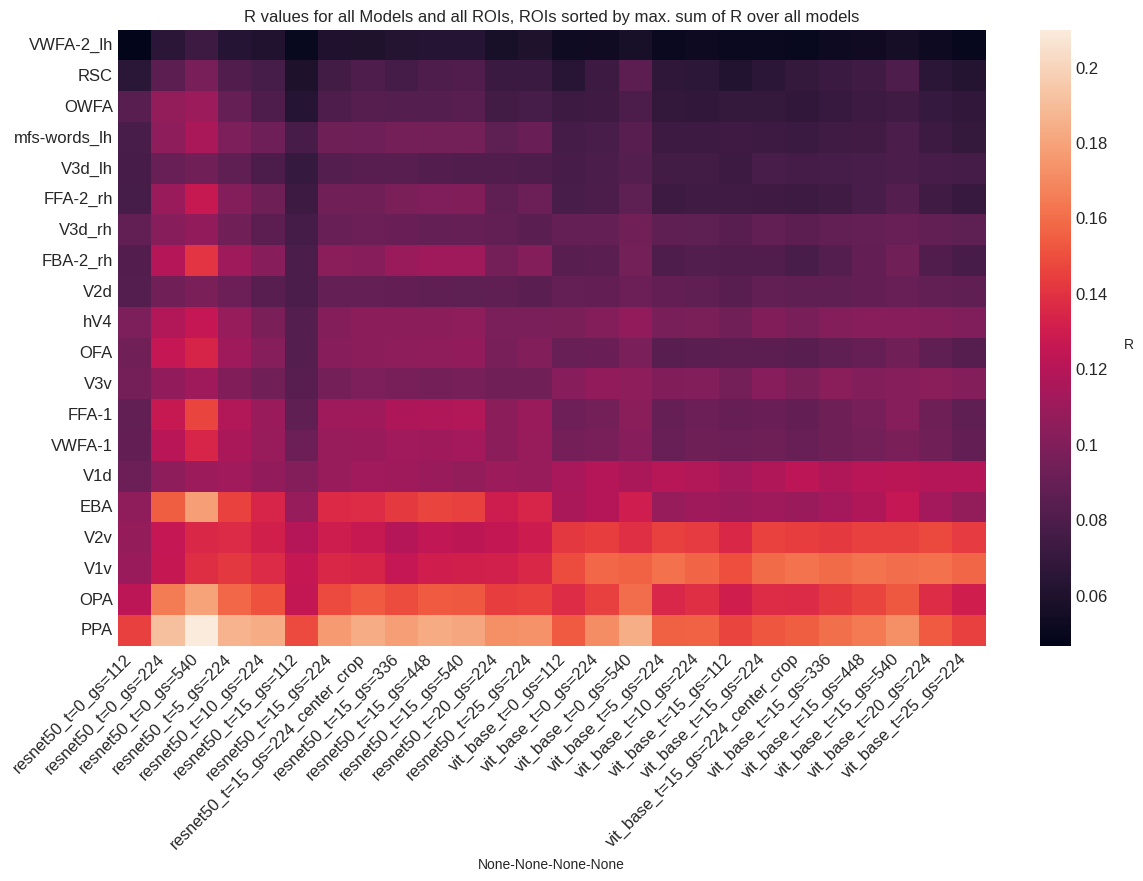

In [12]:
def create_model_labels(cond_tuple):
    if cond_tuple[3]==False:
        return f"{cond_tuple[0]}_t={cond_tuple[1]}_gs={cond_tuple[2]}"
    else:
        return f"{cond_tuple[0]}_t={cond_tuple[1]}_gs={cond_tuple[2]}"+"_center_crop"
fig, ax = plt.subplots(figsize=(14,8))
sns.heatmap(plot_pivot, ax=ax)
model_labels_x = pd.Series(plot_pivot.columns.to_series().apply(create_model_labels))
ax.set_xticklabels(model_labels_x, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
ax.set_ylabel("")
ax.set_title("R values for all Models and all ROIs, ROIs sorted by max. sum of R over all models")
cbar = ax.collections[0].colorbar
cbar.set_label('R', rotation=0, labelpad=15)
cbar.set_ticklabels(np.round(cbar.get_ticks(),2), fontsize=12)
plt.savefig("results/model_comparison/rsa_all_models_all_ROI_heatmap_R.pdf", format='PDF', bbox_inches='tight')
plt.show()

In [6]:
plot_pivot_p = rsa_comp.sort_values("R")
plot_pivot_p["Significance"]=false_discovery_control(plot_pivot_p["Significance"])
plot_pivot_p = pd.pivot_table(data=plot_pivot_p, values="Significance", index="ROI", columns="Model", sort=False) < 0.05

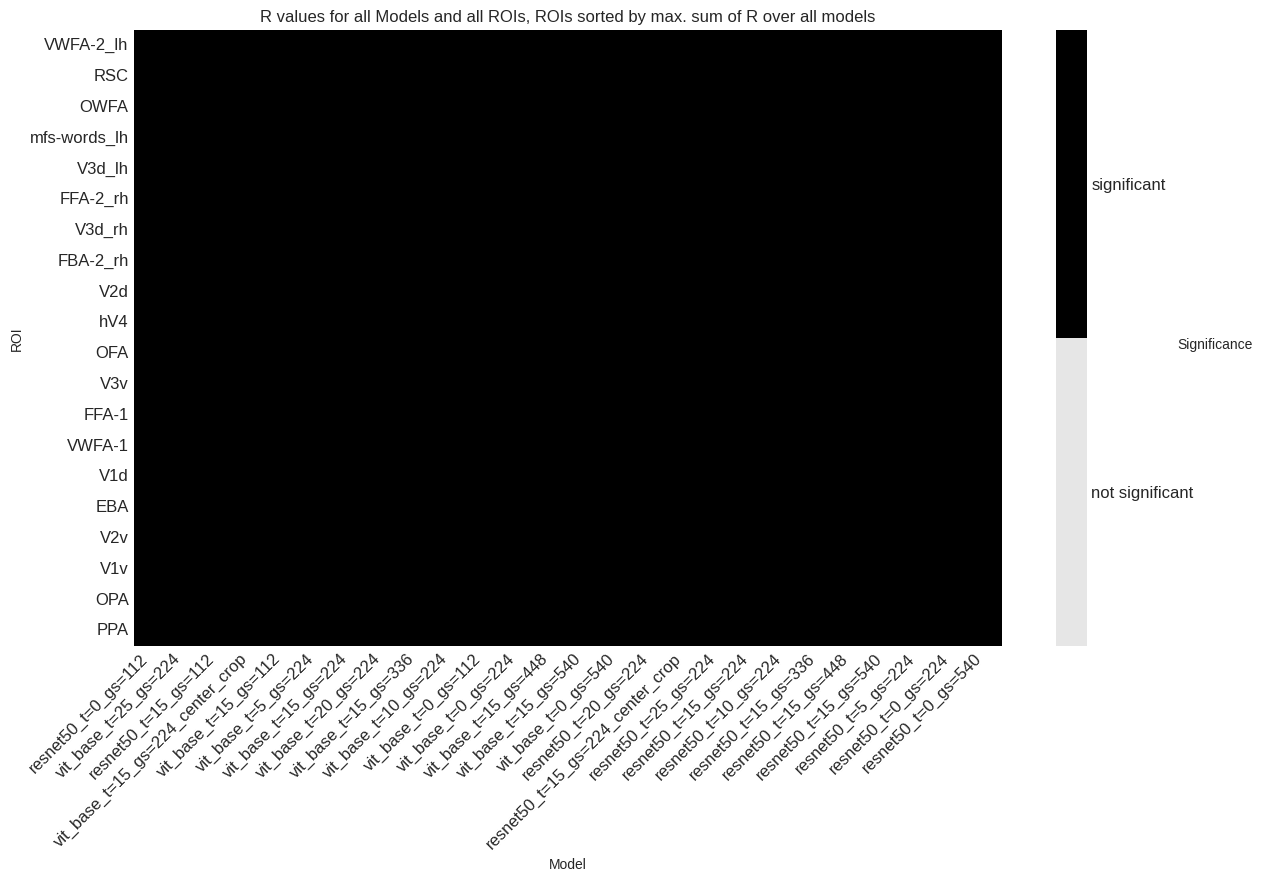

In [7]:
fig, ax = plt.subplots(figsize=(14,8))
palette = sns.color_palette([[0.9,0.9,0.9,1], [0,0,0,1]])
sns.heatmap(plot_pivot_p, ax=ax, cmap=palette, vmin=0, vmax=1)
ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
ax.set_title("R values for all Models and all ROIs, ROIs sorted by max. sum of R over all models")
cbar = ax.collections[0].colorbar
cbar.set_label('Significance', rotation=0, labelpad=15)
cbar.set_ticks([0.25,0.75])
cbar.set_ticklabels(["not significant", "significant"], fontsize=12)
plt.savefig("results/model_comparison/rsa_all_models_all_ROI_heatmap.pdf", format='PDF', bbox_inches='tight')
plt.show()

In [25]:
selectivity_dropdown = widgets.Dropdown(
    options=roi_cat["selectivity"].unique(),
    disabled=False,
)

display(selectivity_dropdown)

Dropdown(options=('basic features', 'body-selective', 'face-selective', 'place-selective', 'word-selective'), …

In [37]:
sel = selectivity_dropdown.value

In [38]:
lineplot_df = rsa_comp.copy()
lineplot_df["ROI_non_handed"] = lineplot_df["ROI"].apply(lambda x: x.split("_")[0])
lineplot_df["selectivity"]=[roi_cat.loc[roi_cat["ROI"]==roi, "selectivity"].values for roi in lineplot_df["ROI_non_handed"].to_list()]
lineplot_df_time=lineplot_df.loc[(lineplot_df["selectivity"]==sel) & 
                                 (lineplot_df["center_crop"]==False) & 
                                 (lineplot_df["crop_size"]==224),:]

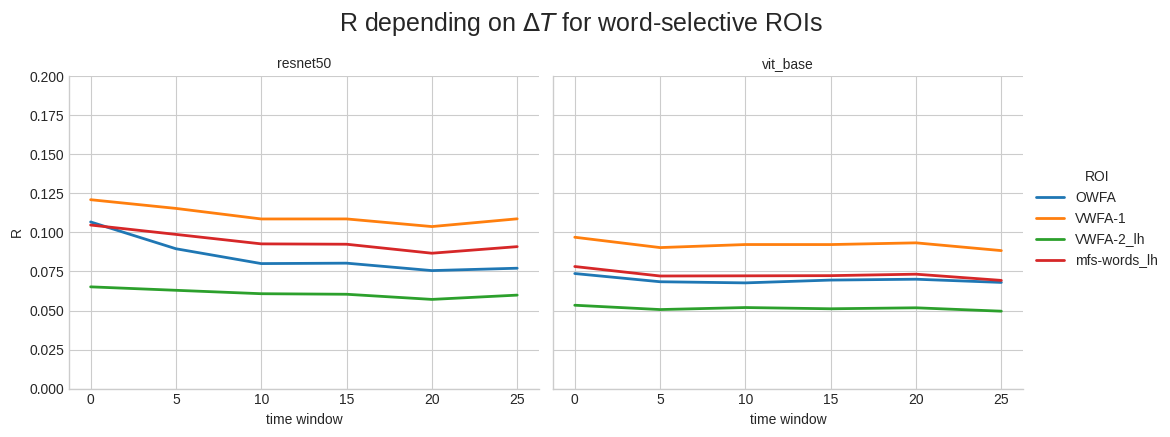

In [39]:
g = sns.FacetGrid(lineplot_df_time, col="model_name", hue="ROI", height=4, aspect=1.3)
g.map(sns.lineplot, "time_window", "R", lw=2)
g.set(ylim=(0,0.2))
g.set_titles("{col_name}")
g.set_xlabels("time window")
g.add_legend()


plt.suptitle(f"R depending on $\Delta T$ for {sel} ROIs", fontsize=18, y=1.08)
plt.savefig(f"results/model_comparison/rsa_R_depending_on_t_{sel}.pdf", format='PDF', bbox_inches='tight')

In [40]:
lineplot_df_crop=lineplot_df.loc[(lineplot_df["selectivity"]==sel) & 
                                 (lineplot_df["center_crop"]==False) & 
                                 (lineplot_df["time_window"]==15),:]

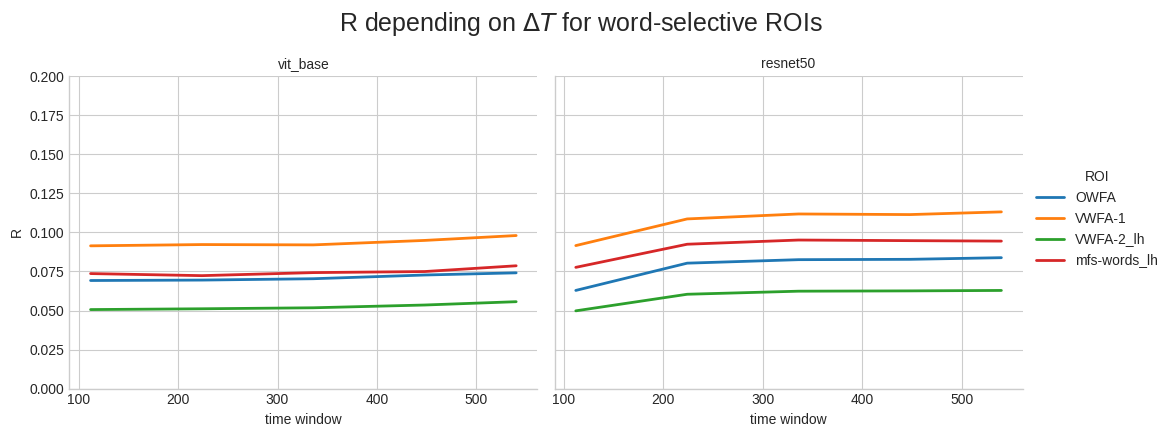

In [41]:
g = sns.FacetGrid(lineplot_df_crop, col="model_name", hue="ROI", height=4, aspect=1.3)
g.map(sns.lineplot, "crop_size", "R", lw=2)
g.set(ylim=(0,0.2))
g.set_titles("{col_name}")
g.set_xlabels("time window")
g.add_legend()


plt.suptitle(f"R depending on $\Delta T$ for {sel} ROIs", fontsize=18, y=1.08)
plt.savefig(f"results/model_comparison/rsa_R_depending_on_crop_size_{sel}.pdf", format='PDF', bbox_inches='tight')